In [1]:
# 1) ดาวน์โหลด/ติดตั้ง Sarabun
!mkdir -p /usr/local/share/fonts/truetype/sarabun
!wget -q -O /usr/local/share/fonts/truetype/sarabun/Sarabun-Regular.ttf https://github.com/google/fonts/raw/main/ofl/sarabun/Sarabun-Regular.ttf
!wget -q -O /usr/local/share/fonts/truetype/sarabun/Sarabun-Bold.ttf https://github.com/google/fonts/raw/main/ofl/sarabun/Sarabun-Bold.ttf
!wget -q -O /usr/local/share/fonts/truetype/sarabun/Sarabun-Italic.ttf https://github.com/google/fonts/raw/main/ofl/sarabun/Sarabun-Italic.ttf
!wget -q -O /usr/local/share/fonts/truetype/sarabun/Sarabun-BoldItalic.ttf https://github.com/google/fonts/raw/main/ofl/sarabun/Sarabun-BoldItalic.ttf
!fc-cache -fv
!pip -q install adjustText

# บอก Matplotlib ให้รู้จักไฟล์ฟอนต์ที่เพิ่งลง
import matplotlib.font_manager as fm
for f in fm.findSystemFonts(fontpaths=['/usr/local/share/fonts/truetype/sarabun'], fontext='ttf'):
    fm.fontManager.addfont(f)

The syntax of the command is incorrect.
'wget' is not recognized as an internal or external command,
operable program or batch file.
'wget' is not recognized as an internal or external command,
operable program or batch file.
'wget' is not recognized as an internal or external command,
operable program or batch file.
'wget' is not recognized as an internal or external command,
operable program or batch file.
'fc-cache' is not recognized as an internal or external command,
operable program or batch file.

[notice] A new release of pip is available: 25.0 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from matplotlib import rcParams

plt.style.use('seaborn-v0_8')   # 'default', 'classic', 'dark_background', etc.
# plt.style.use('ggplot')   # 'default', 'classic', 'dark_background', etc.

# ตรวจสอบว่ามี Tahoma ในรายการฟอนต์หรือไม่
available_fonts = sorted({f.name for f in fm.fontManager.ttflist})

if 'Tahoma' in available_fonts:
    rcParams['font.family'] = 'Tahoma'
elif 'Sarabun' in available_fonts:
    rcParams['font.family'] = 'Sarabun'

In [3]:
import matplotlib.ticker as mtick
from adjustText import adjust_text

# ข้อมูลทั้งประเทศ

In [ ]:
raw_url = 'https://github.com/nopchok/mini-project/raw/refs/heads/main/data/wikipedia%20%E0%B8%AD%E0%B8%B1%E0%B8%99%E0%B8%94%E0%B8%B1%E0%B8%9A%E0%B8%A1%E0%B8%AB%E0%B8%B2%E0%B8%A7%E0%B8%B4%E0%B8%97%E0%B8%A2%E0%B8%B2%E0%B8%A5%E0%B8%B1%E0%B8%A2%E0%B9%84%E0%B8%97%E0%B8%A2.xlsx'
df_rank = pd.read_excel(raw_url, header=None)
df_rank

,0,1,2,3,4,5,6,7,8,9,10,11,12
0,https://th.wikipedia.org/wiki/%E0%B8%AD%E0%B8%...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,สถาบัน,2017[9],NaN,2018-19[10],NaN,2019-20[11],NaN,2020-21[12],NaN,2021-22[13],NaN,2024[14],NaN
2,NaN,อันดับในประเทศ,อันดับโลก,อันดับในประเทศ,อันดับโลก,อันดับในประเทศ,อันดับโลก,อันดับในประเทศ,อันดับโลก,อันดับในประเทศ,อันดับโลก,อันดับในประเทศ,อันดับโลก
3,จุฬาลงกรณ์มหาวิทยาลัย,1,308,2,488,1,486,1,493,1,484,1,472
4,มหาวิทยาลัยมหิดล,2,518,1,471,2,500,2,561,2,549,2,527
5,มหาวิทยาลัยเชียงใหม่,3,846,3,793,3,924,3,930,3,944,3,894
6,มหาวิทยาลัยขอนแก่น,NaN,NaN,4,990,5,1107,5,1174,4,1172,4,1182
7,มหาวิทยาลัยสงขลานครินทร์,NaN,NaN,NaN,NaN,4,1104,4,1161,5,1185,5,1258
8,มหาวิทยาลัยเกษตรศาสตร์,NaN,NaN,NaN,NaN,6,1191,6,1243,6,1252,6,1304
9,มหาวิทยาลัยเทคโนโลยีพระจอมเกล้าธนบุรี,NaN,NaN,NaN,NaN,7,1456,7,1500,7,1551,7,1657


In [6]:
df_rank_2024 = df_rank.copy()
df_rank_2024 = df_rank_2024.iloc[3:, [0] + list(range(df_rank_2024.shape[1]-2, df_rank_2024.shape[1]))]
df_rank_2024.reset_index(inplace=True, drop=True)
df_rank_2024.columns = ['สถาบัน', 'อันดับในประเทศ', 'อันดับโลก']
df_rank_2024

,สถาบัน,อันดับในประเทศ,อันดับโลก
0,จุฬาลงกรณ์มหาวิทยาลัย,1,472
1,มหาวิทยาลัยมหิดล,2,527
2,มหาวิทยาลัยเชียงใหม่,3,894
3,มหาวิทยาลัยขอนแก่น,4,1182
4,มหาวิทยาลัยสงขลานครินทร์,5,1258
5,มหาวิทยาลัยเกษตรศาสตร์,6,1304
6,มหาวิทยาลัยเทคโนโลยีพระจอมเกล้าธนบุรี,7,1657
7,มหาวิทยาลัยธรรมศาสตร์,8,1663
8,มหาวิทยาลัยแม่ฟ้าหลวง,9,1692
9,มหาวิทยาลัยเทคโนโลยีสุรนารี,10,1693


In [ ]:
raw_url = 'https://github.com/nopchok/mini-project/raw/refs/heads/main/data/%E0%B8%A0%E0%B8%B2%E0%B8%9E%E0%B8%A3%E0%B8%A7%E0%B8%A1%E0%B8%A0%E0%B8%B2%E0%B8%A7%E0%B8%B0%E0%B8%81%E0%B8%B2%E0%B8%A3%E0%B8%97%E0%B8%B3%E0%B8%87%E0%B8%B2%E0%B8%99%20%E0%B8%9B%E0%B8%B5%2066%20%E0%B8%97%E0%B8%B1%E0%B9%89%E0%B8%87%E0%B8%9B%E0%B8%A3%E0%B8%B0%E0%B9%80%E0%B8%97%E0%B8%A8.xlsx'
df_overall = pd.read_excel(raw_url)
print(f'Data rows : {df_overall.shape[0]}')
print(df_overall.columns)

Data rows : 173
Index(['หมวดมหาวิทยาลัย', 'ชื่อสถาบันอุดมศึกษา', 'ทำงานแล้ว',
       'ทำงานแล้วและกำลังศึกษาต่อ', 'ยังไม่ได้ทำงานและมิได้ศึกษาต่อ',
       'กำลังศึกษาต่อ', 'รวมทั้งหมด', '%ทำงานแล้ว',
       '%ทำงานแล้วและกำลังศึกษาต่อ', '%ยังไม่ได้ทำงานและมิได้ศึกษาต่อ',
       '%กำลังศึกษาต่อ'],
      dtype='object')


In [8]:
s1 = pd.Series(df_rank_2024['สถาบัน'].unique())

s2 = pd.Series(df_overall['ชื่อสถาบันอุดมศึกษา'].unique())

print( 'รายชื่อสถาบันที่ไม่มีอยู่ใน ข้อมูลภาวะการได้งานของทั้งประเทศ' )
s1[s1.isin(s2)==False].tolist()

รายชื่อสถาบันที่ไม่มีอยู่ใน ข้อมูลภาวะการได้งานของทั้งประเทศ


['มหาวิทยาลัยเกษตรศาสตร์']

In [9]:
df_overall['ชื่อสถาบันอุดมศึกษา'][df_overall['ชื่อสถาบันอุดมศึกษา'].str.contains("เกษตร", na=False)]

148    มหาวิทยาลัยเกษตรศาสตร์ วิทยาเขตเฉลิมพระเกียรติ...
151               มหาวิทยาลัยเกษตรศาสตร์ วิทยาเขตศรีราชา
159              มหาวิทยาลัยเกษตรศาสตร์ วิทยาเขตกำแพงแสน
164                        มหาวิทยาลัยเกษตรศาสตร์ บางเขน
Name: ชื่อสถาบันอุดมศึกษา, dtype: object

In [10]:
# แก้ไข มหาวิทยาลัยเกษตรศาสตร์ ใน df_rank_2024 ให้ตรงกับ df_overall
df_rank_2024_adj = df_rank_2024.copy()
df_rank_2024_adj.loc[
    df_rank_2024_adj['สถาบัน'] == 'มหาวิทยาลัยเกษตรศาสตร์',
    'สถาบัน'
] = 'มหาวิทยาลัยเกษตรศาสตร์ บางเขน'
df_rank_2024_adj

,สถาบัน,อันดับในประเทศ,อันดับโลก
0,จุฬาลงกรณ์มหาวิทยาลัย,1,472
1,มหาวิทยาลัยมหิดล,2,527
2,มหาวิทยาลัยเชียงใหม่,3,894
3,มหาวิทยาลัยขอนแก่น,4,1182
4,มหาวิทยาลัยสงขลานครินทร์,5,1258
5,มหาวิทยาลัยเกษตรศาสตร์ บางเขน,6,1304
6,มหาวิทยาลัยเทคโนโลยีพระจอมเกล้าธนบุรี,7,1657
7,มหาวิทยาลัยธรรมศาสตร์,8,1663
8,มหาวิทยาลัยแม่ฟ้าหลวง,9,1692
9,มหาวิทยาลัยเทคโนโลยีสุรนารี,10,1693


In [11]:
# join 2 dataframe
df_overall_rank = df_overall.merge(
    df_rank_2024_adj,
    how="inner",
    left_on="ชื่อสถาบันอุดมศึกษา",
    right_on="สถาบัน"
)
df_overall_rank

,หมวดมหาวิทยาลัย,ชื่อสถาบันอุดมศึกษา,ทำงานแล้ว,ทำงานแล้วและกำลังศึกษาต่อ,ยังไม่ได้ทำงานและมิได้ศึกษาต่อ,กำลังศึกษาต่อ,รวมทั้งหมด,%ทำงานแล้ว,%ทำงานแล้วและกำลังศึกษาต่อ,%ยังไม่ได้ทำงานและมิได้ศึกษาต่อ,%กำลังศึกษาต่อ,สถาบัน,อันดับในประเทศ,อันดับโลก
0,มหาวิทยาลัยในกำกับรัฐ,จุฬาลงกรณ์มหาวิทยาลัย,982,0,0,0,982,1.000000,0.000000,0.000000,0.000000,จุฬาลงกรณ์มหาวิทยาลัย,1,472
1,มหาวิทยาลัยในกำกับรัฐ,มหาวิทยาลัยธรรมศาสตร์,457,10,104,52,623,0.733547,0.016051,0.166934,0.083467,มหาวิทยาลัยธรรมศาสตร์,8,1663
2,มหาวิทยาลัยในกำกับรัฐ,มหาวิทยาลัยเชียงใหม่,3682,247,991,311,5231,0.703881,0.047219,0.189448,0.059453,มหาวิทยาลัยเชียงใหม่,3,894
3,มหาวิทยาลัยในกำกับรัฐ,มหาวิทยาลัยแม่ฟ้าหลวง,1963,89,635,150,2837,0.691928,0.031371,0.223828,0.052873,มหาวิทยาลัยแม่ฟ้าหลวง,9,1692
4,มหาวิทยาลัยในกำกับรัฐ,มหาวิทยาลัยมหิดล,2578,150,797,299,3824,0.674163,0.039226,0.208421,0.078190,มหาวิทยาลัยมหิดล,2,527
5,มหาวิทยาลัยในกำกับรัฐ,มหาวิทยาลัยขอนแก่น,3502,174,1382,272,5330,0.657036,0.032645,0.259287,0.051032,มหาวิทยาลัยขอนแก่น,4,1182
6,มหาวิทยาลัยในกำกับรัฐ,มหาวิทยาลัยเทคโนโลยีสุรนารี,762,4,346,66,1178,0.646859,0.003396,0.293718,0.056027,มหาวิทยาลัยเทคโนโลยีสุรนารี,10,1693
7,มหาวิทยาลัยในกำกับรัฐ,มหาวิทยาลัยเทคโนโลยีพระจอมเกล้าธนบุรี,1942,30,985,140,3097,0.627058,0.009687,0.318050,0.045205,มหาวิทยาลัยเทคโนโลยีพระจอมเกล้าธนบุรี,7,1657
8,มหาวิทยาลัยในกำกับรัฐ,มหาวิทยาลัยสงขลานครินทร์,1904,68,905,189,3066,0.621005,0.022179,0.295173,0.061644,มหาวิทยาลัยสงขลานครินทร์,5,1258
9,มหาวิทยาลัยในกำกับรัฐ,มหาวิทยาลัยเกษตรศาสตร์ บางเขน,3814,27,3263,618,7722,0.493913,0.003497,0.422559,0.080031,มหาวิทยาลัยเกษตรศาสตร์ บางเขน,6,1304


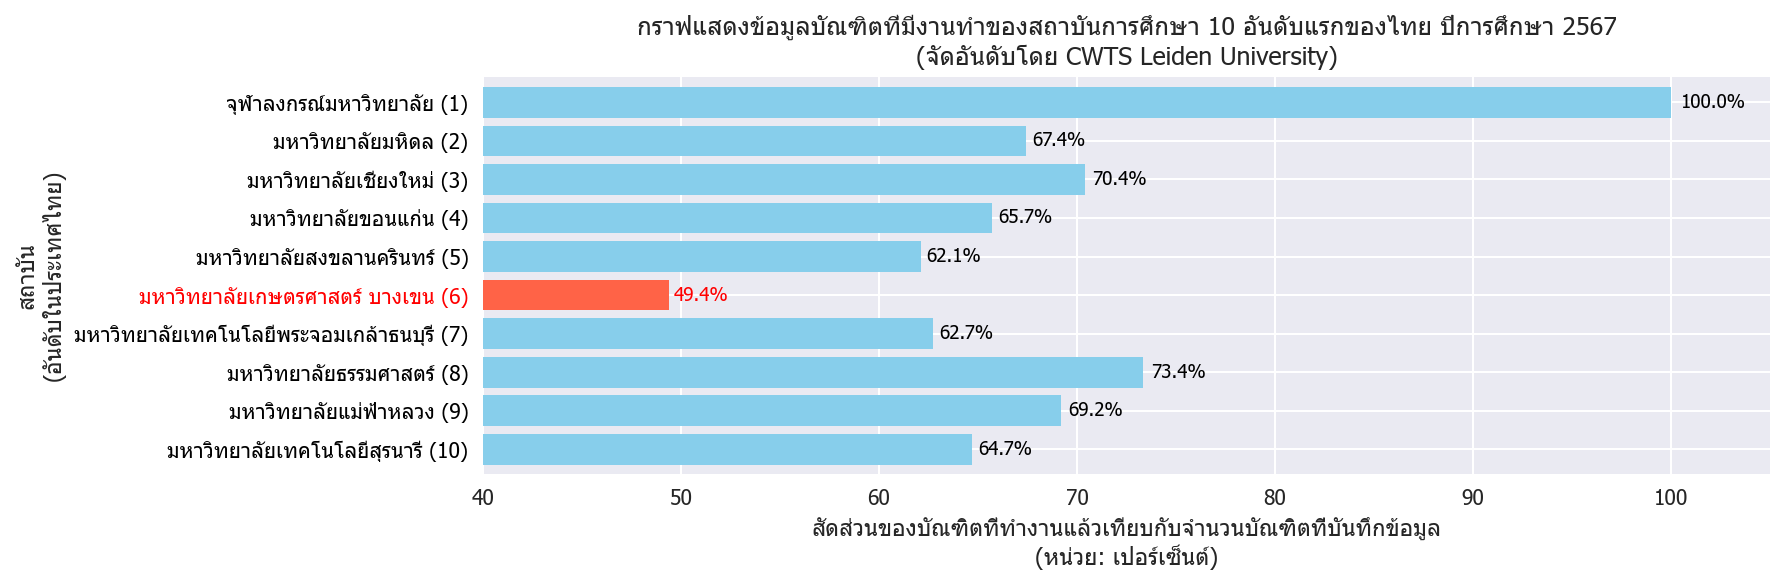

In [25]:
df_plot = df_overall_rank.copy()
df_plot['%ทำงานแล้ว'] = df_plot['%ทำงานแล้ว'] * 100
df_plot.sort_values(by='อันดับในประเทศ', inplace=True, ascending=False)
df_plot['ชื่อสถาบันอุดมศึกษา'] = df_plot['ชื่อสถาบันอุดมศึกษา'] + ' (' + df_plot['อันดับในประเทศ'].astype(str) + ')'
df_plot = df_plot[['ชื่อสถาบันอุดมศึกษา', '%ทำงานแล้ว']]

df_plot.set_index('ชื่อสถาบันอุดมศึกษา', inplace=True)

# หาตำแหน่ง index ของค่าต่ำสุด
min_idx = df_plot['%ทำงานแล้ว'].idxmin()

# สร้าง list สี ยาวเท่ากับจำนวนแถว
colors = ['skyblue'] * len(df_plot)
colors[df_plot.index.get_loc(min_idx)] = 'tomato'


plt.figure(figsize=(12,4), dpi=150)

ax = df_plot['%ทำงานแล้ว'].plot(kind='barh',
    color=colors,
    width=0.8,
    ax=plt.gca(),
    legend=False
    )

min_value = df_plot['%ทำงานแล้ว'].min()
left_limit = np.floor(min_value / 10) * 10
ax.set_xlim(left=left_limit)


min_pos = df_plot.index.get_loc(min_idx)
for i, val in enumerate(df_plot['%ทำงานแล้ว']):
    if i == min_pos:
        txt_color = 'red'
    else:
        txt_color = 'black'
    ax.text(val*1.005, i, f'{val:,.1f}%', va='center', fontsize=9, color=txt_color)


y_labels = ax.get_yticklabels()
for i, label in enumerate(y_labels):
    if i == min_pos:
        label.set_color('red')
    else:
        label.set_color('black')


plt.xlabel("สัดส่วนของบัณฑิตที่ทำงานแล้วเทียบกับจำนวนบัณฑิตที่บันทึกข้อมูล\n(หน่วย: เปอร์เซ็นต์)")
plt.ylabel("สถาบัน\n(อันดับในประเทศไทย)")
plt.title("กราฟแสดงข้อมูลบัณฑิตที่มีงานทำของสถาบันการศึกษา 10 อันดับแรกของไทย ปีการศึกษา 2567\n(จัดอันดับโดย CWTS Leiden University)")
plt.tight_layout()
plt.show()

# วิเคราะห์ Data จากมหาวิทยาลัยเกษตรศาสตร์

In [ ]:
raw_url = 'https://github.com/nopchok/mini-project/raw/refs/heads/main/python_code/all_result_clean.xlsx'
df_original = pd.read_excel(raw_url, index_col=0)
print(f'Data rows : {df_original.shape[0]}')

Data rows : 4157


# ภาพรวมของแต่ละระดับ

In [27]:
df = df_original.copy()
out = (
    df.groupby('ระดับ')
      .agg(
          จำนวนผู้บันทึกข้อมูล=('ผู้บันทึกข้อมูล', 'sum'),
          จำนวนมีงานเดิม=('มีงานทำเดิม', 'sum')
      )
)
out['ร้อยละมีงานเดิม'] = (out['จํานวนมีงานเดิม'] / out['จํานวนผู้บันทึกข้อมูล'] * 100).round(2)


def style_not_max(val, attr=''):
  return np.where(val != np.nanmax(val.values), attr, '')
def style_max(val, attr=''):
  return np.where(val == np.nanmax(val.values), attr, '')
def stripe_rows(row):
    color = '#f2f2f2' if row.name % 2 == 0 else 'white'
    return [f'background-color: {color}; color: black;' for _ in row]

custom_styles = [
    dict(selector="th", props=[("background-color", "white"),("color", "black"),('border-bottom', '1px solid #a2a2a2')]),
]

out.reset_index(inplace=True)
out.style.set_table_styles(custom_styles) \
        .format( formatter={'ร้อยละมีงานเดิม':'{:.2f}%', 'จํานวนผู้บันทึกข้อมูล': '{:,}', 'จํานวนมีงานเดิม': '{:,}'} ) \
        .apply(stripe_rows, axis=1) \
        .apply(style_max, attr='color:black;background-color:yellow;', axis=0, subset=out.columns[-3:]) \
        .apply(style_not_max, axis=0).hide(axis="index")

ระดับ,จํานวนผู้บันทึกข้อมูล,จํานวนมีงานเดิม,ร้อยละมีงานเดิม
ป.ตรี,"113,008","5,008",4.43%
ปริญญาเอก,"1,994",545,27.33%
ปริญญาโท,"17,176","9,522",55.44%


# การบันทึกข้อมูลของบัณฑิต มหาวิทยาลัยเกษตรศาสตร์

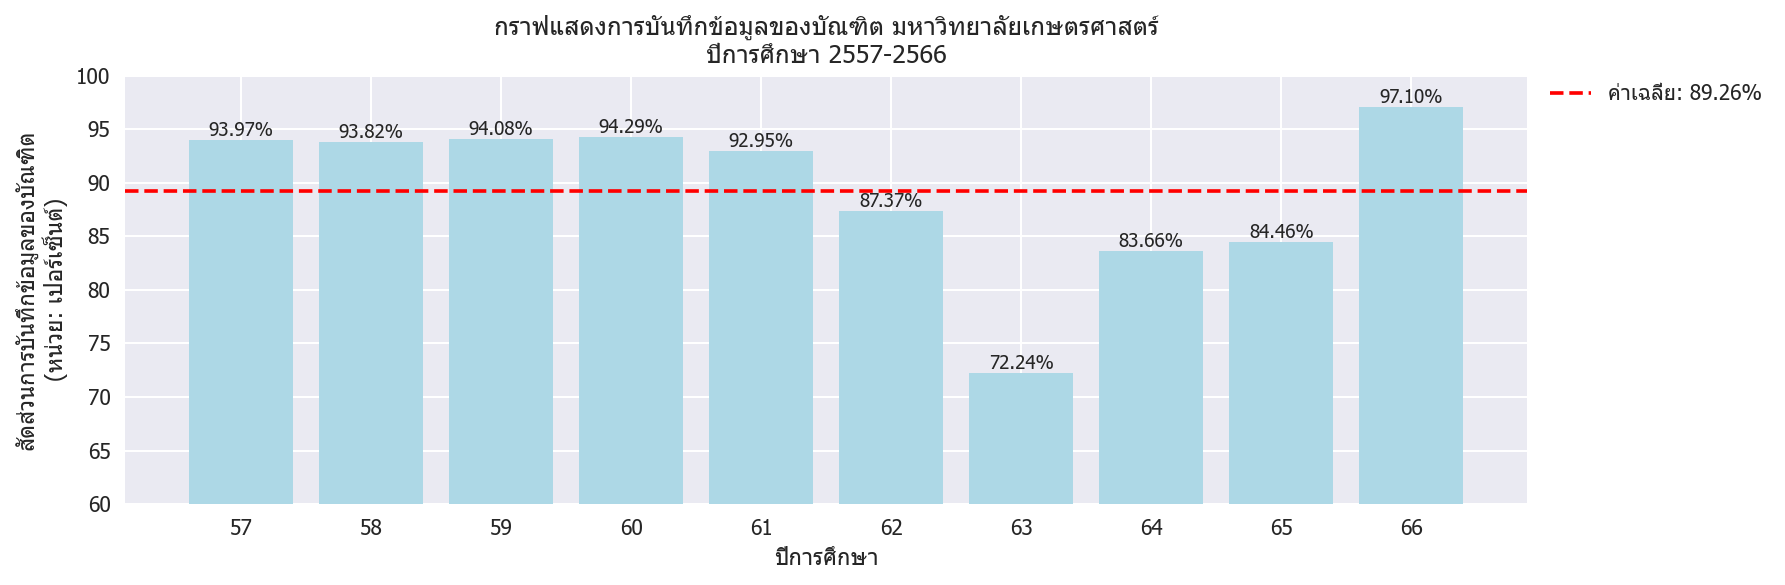

In [28]:
df = df_original.copy()
filtered_df_ptree = df[df['ระดับ'] == 'ป.ตรี']

# Sum per year
yearly_summary = (
    filtered_df_ptree.groupby('ปี')[['ผู้บันทึกข้อมูล', 'ผู้สำเร็จการศึกษา']]
    .sum()
    .reset_index()
    .sort_values('ปี')
)

# % บันทึกข้อมูล
den = yearly_summary['ผู้สำเร็จการศึกษา']
num = yearly_summary['ผู้บันทึกข้อมูล']
yearly_summary['%บันทึกข้อมูล'] = np.where(den > 0, (num / den) * 100, 0)

# ค่าเฉลี่ยรวม
total_den = den.sum()
total_num = num.sum()
average_percentage = (total_num / total_den) * 100 if total_den > 0 else 0

# Plot
plt.figure(figsize=(12,4), dpi=150)
plt.bar(yearly_summary['ปี'].astype(str), yearly_summary['%บันทึกข้อมูล'], color='lightblue')

# เส้นค่าเฉลี่ย
plt.axhline(average_percentage, linestyle='--', label=f'ค่าเฉลี่ย: {average_percentage:.2f}%', color='red')

# Data labels
ax = plt.gca()
for bar in ax.patches:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, yval, f'{yval:.2f}%', ha='center', va='bottom', fontsize=9)


# ย้าย legend ออกด้านข้างขวา
plt.legend()
ax.legend(
    bbox_to_anchor=(1.01, 1),
    loc='upper left',
    borderaxespad=0
)
ax.set_ylim(60, 100)

plt.xticks(rotation=0)
plt.xlabel("ปีการศึกษา")
plt.ylabel("สัดส่วนการบันทึกข้อมูลของบัณฑิต\n(หน่วย: เปอร์เซ็นต์)")
plt.title("กราฟแสดงการบันทึกข้อมูลของบัณฑิต มหาวิทยาลัยเกษตรศาสตร์\nปีการศึกษา 2557-2566")
plt.tight_layout()
plt.show()

# แนวโน้มไม่ประสงค์ทำงาน เพิ่มขึ้น ?

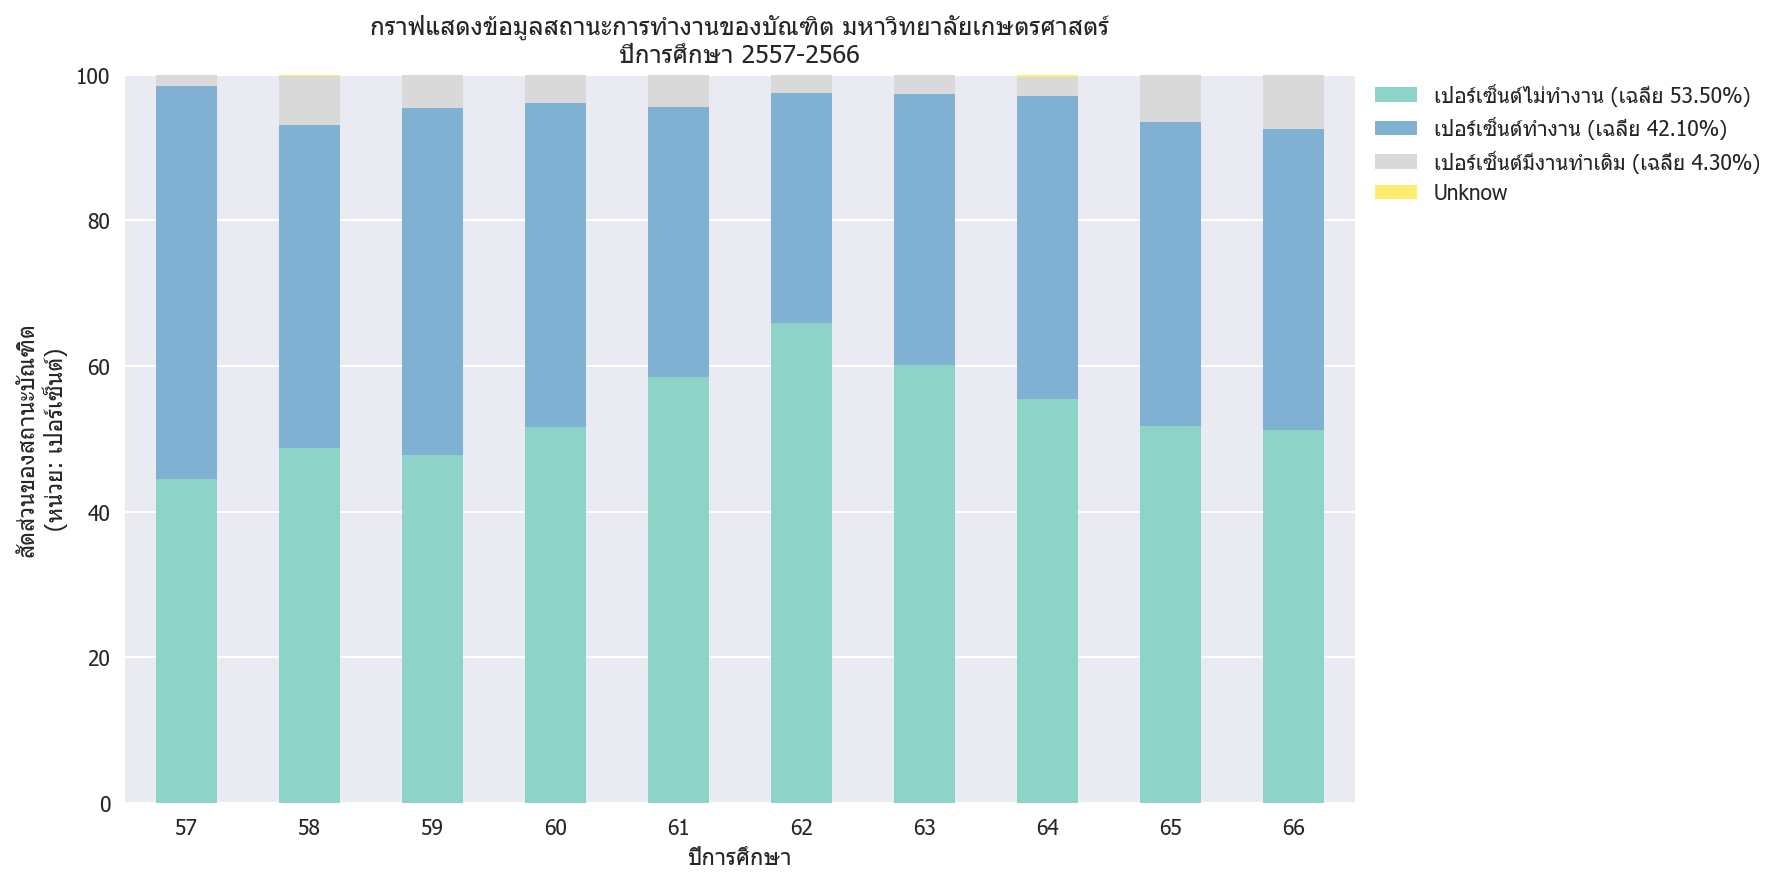

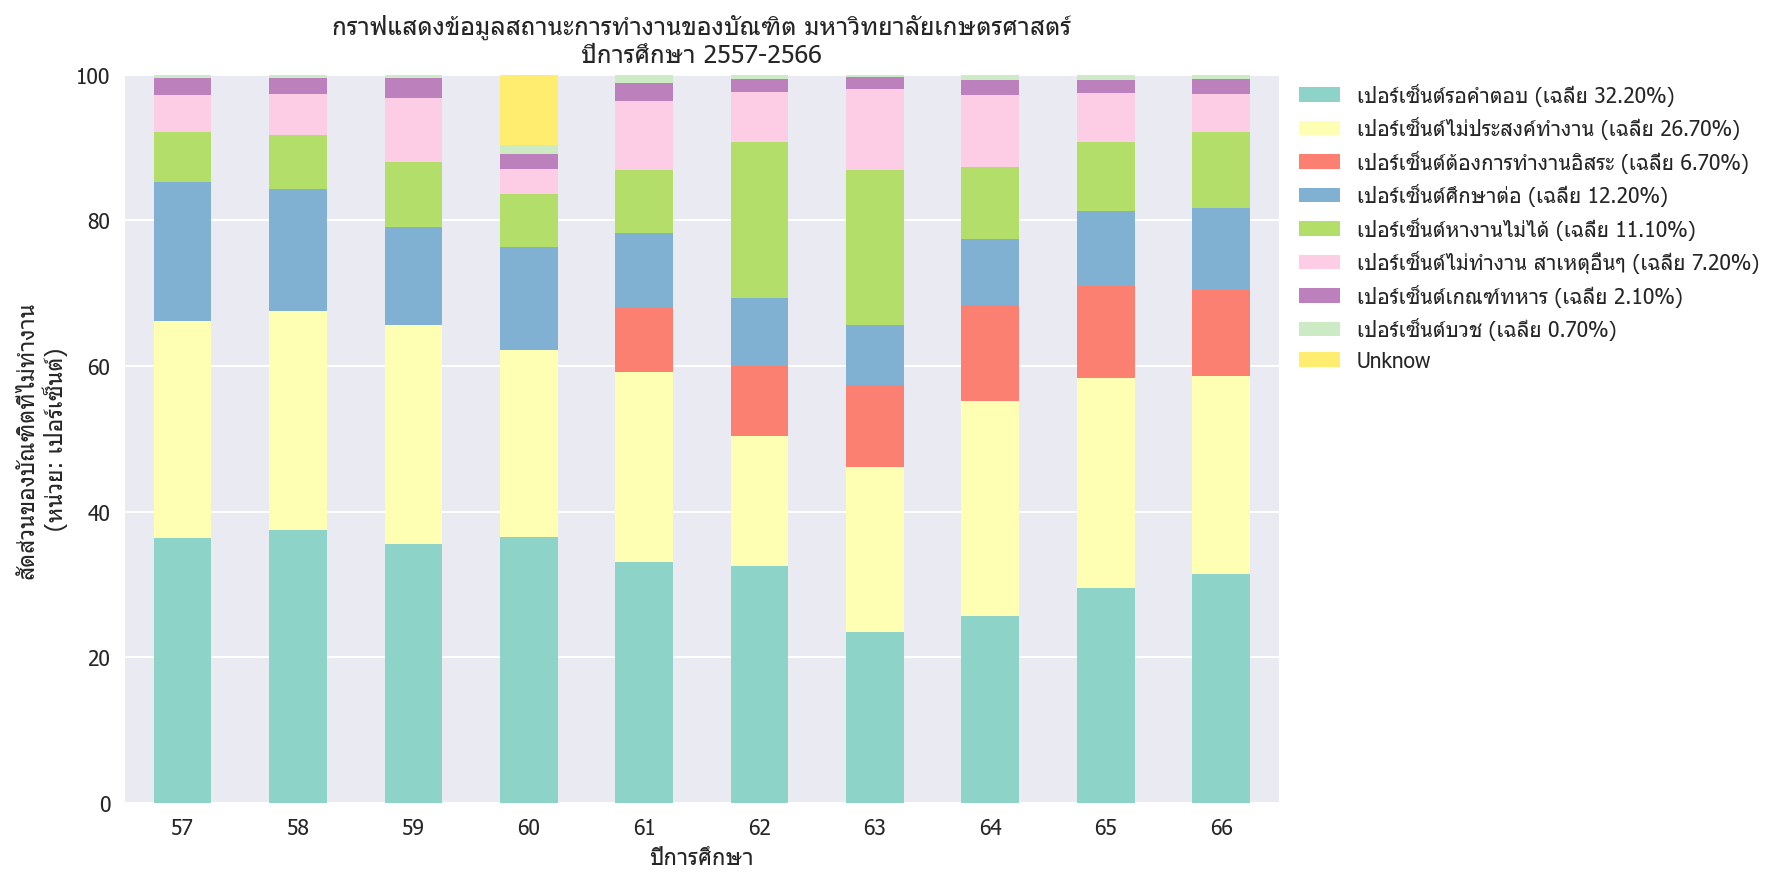

In [30]:
df = df_original.copy()
df = df[df['ระดับ'] == 'ป.ตรี']

group_overall = ["ผู้บันทึกข้อมูล", "ทำงาน", "ไม่ทำงาน", 'มีงานทำเดิม']
group_working = ['ทำงาน', 'รัฐ', 'รัฐวิสาหกิจ', 'เอกชน', 'ธุรกิจส่วนตัว/อิสระ', 'องค์การระหว่างประเทศ', 'ทำงานที่อื่นๆ']
group_working_matched = ['ทำงาน', 'งานตรงสาขา', 'งานไม่ตรงสาขา', 'งานไม่ระบุสาขา']
group_no_working = ['ไม่ทำงาน', 'ไม่ประสงค์ทำงาน', 'หางานไม่ได้', 'ศึกษาต่อ', 'บวช'
                    , 'เกณฑ์ทหาร', 'ต้องการทำงานอิสระ', 'ไม่ทำงาน สาเหตุอื่นๆ', 'รอคำตอบ']

make_plot = {
  'สัดส่วนผู้บันทึกข้อมูล ตามปี' : group_overall,
  'สัดส่วนกลุ่มไม่ทำงาน ตามปี' : group_no_working,
}

titles = {
  'สัดส่วนผู้บันทึกข้อมูล ตามปี' : 'กราฟแสดงข้อมูลสถานะการทำงานของบัณฑิต มหาวิทยาลัยเกษตรศาสตร์\nปีการศึกษา 2557-2566',
  'สัดส่วนกลุ่มไม่ทำงาน ตามปี' : 'กราฟแสดงข้อมูลสถานะการทำงานของบัณฑิต มหาวิทยาลัยเกษตรศาสตร์\nปีการศึกษา 2557-2566',
}
ylabels = {
  'สัดส่วนผู้บันทึกข้อมูล ตามปี' : 'สัดส่วนของสถานะบัณฑิต\n(หน่วย: เปอร์เซ็นต์)',
  'สัดส่วนกลุ่มไม่ทำงาน ตามปี' : 'สัดส่วนของบัณฑิตที่ไม่ทำงาน\n(หน่วย: เปอร์เซ็นต์)',
}

for key, target_group in make_plot.items():
    group_all = target_group[0]
    group_each = target_group[1:]
    df_grouped = df.groupby("ปี")[[group_all] + group_each].sum()

    for k in group_each:
        df_grouped["เปอร์เซ็นต์" + k] = (
            df_grouped[k] / df_grouped[group_all] * 100
        )
    df_grouped = df_grouped.iloc[:, -len(group_each):]
    df_grouped["Unknow"] = 100 - (df_grouped.iloc[:, -len(group_each):]).sum(axis=1)
    df_grouped.loc[df_grouped["Unknow"] < 0, "Unknow"] = 0
    df_grouped.sort_values(by=66, axis=1, ascending=False, inplace=True)

    avg_values = df_grouped.mean().round(1)

    plt.figure(figsize=(12,6), dpi=150)

    # plot stacked bar
    ax = df_grouped.plot(
        y=df_grouped.columns[-len(group_each)-1:],
        kind='bar',
        stacked=True,
        colormap='Set3',
        ax=plt.gca()
    )

    handles, labels = ax.get_legend_handles_labels()
    new_labels = [lbl if lbl=='Unknow' else f"{lbl} (เฉลี่ย {avg_values[lbl]:.2f}%)" for lbl in labels]

    # ย้าย legend ออกด้านข้างขวา
    ax.legend(
        handles, new_labels,
        bbox_to_anchor=(1.01, 1),
        loc='upper left',
        borderaxespad=0
    )

    ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
    ax.set_ylim(0, 100)

    plt.ylabel(ylabels[key])
    plt.xlabel("ปีการศึกษา")
    plt.title(titles[key])
    plt.tight_layout()  # ปรับ layout ให้ไม่บัง
    plt.show()

# งานตรงสาขา

In [ ]:
raw_url = 'https://github.com/nopchok/mini-project/raw/refs/heads/main/data/%E0%B8%81%E0%B8%A5%E0%B8%B8%E0%B9%88%E0%B8%A1%E0%B8%98%E0%B8%B8%E0%B8%A3%E0%B8%81%E0%B8%B4%E0%B8%88.xlsx'
raw_url = '../data/กลุ่มธุรกิจ.xlsx'
df_business = pd.read_excel(raw_url)
df_business

,คณะ|สาขา,กลุ่มธุรกิจ
0,เกษตร|วิทยาศาสตรบัณฑิต สาขาเกษตรเขตร้อน,เกษตร
1,เกษตร|วิทยาศาสตรบัณฑิต สาขาเกษตรศาสตร์,เกษตร
2,เกษตร|วิทยาศาสตรบัณฑิต สาขาเคมีการเกษตร,เกษตร
3,เกษตร|วิทยาศาสตรบัณฑิต สาขาเครื่องจักรกลและเมค...,เกษตร
4,เกษตร|วิทยาศาสตรบัณฑิต สาขาเทคโนโลยีชีวภาพทางก...,เกษตร
...,...,...
197,อุตสาหกรรมเกษตร|วิทยาศาสตรบัณฑิต สาขานวัตกรรมแ...,เกษตร
198,อุตสาหกรรมเกษตร|วิทยาศาสตรบัณฑิต สาขาพัฒนาผลิต...,เกษตร
199,อุตสาหกรรมเกษตร|วิทยาศาสตรบัณฑิต สาขาวิทยาศาสต...,อาหาร
200,อุตสาหกรรมเกษตร|วิทยาศาสตรบัณฑิต สาขาวิทยาศาสต...,สิ่งทอ


In [105]:
df = df_original.copy()

df["คณะ|สาขา"] = df['คณะ'] + '|' + df['สาขา']
df = df.merge(
    df_business,
    how="inner",
    left_on="คณะ|สาขา",
    right_on="คณะ|สาขา"
)
df['กลุ่มธุรกิจ'].isna().sum()

0

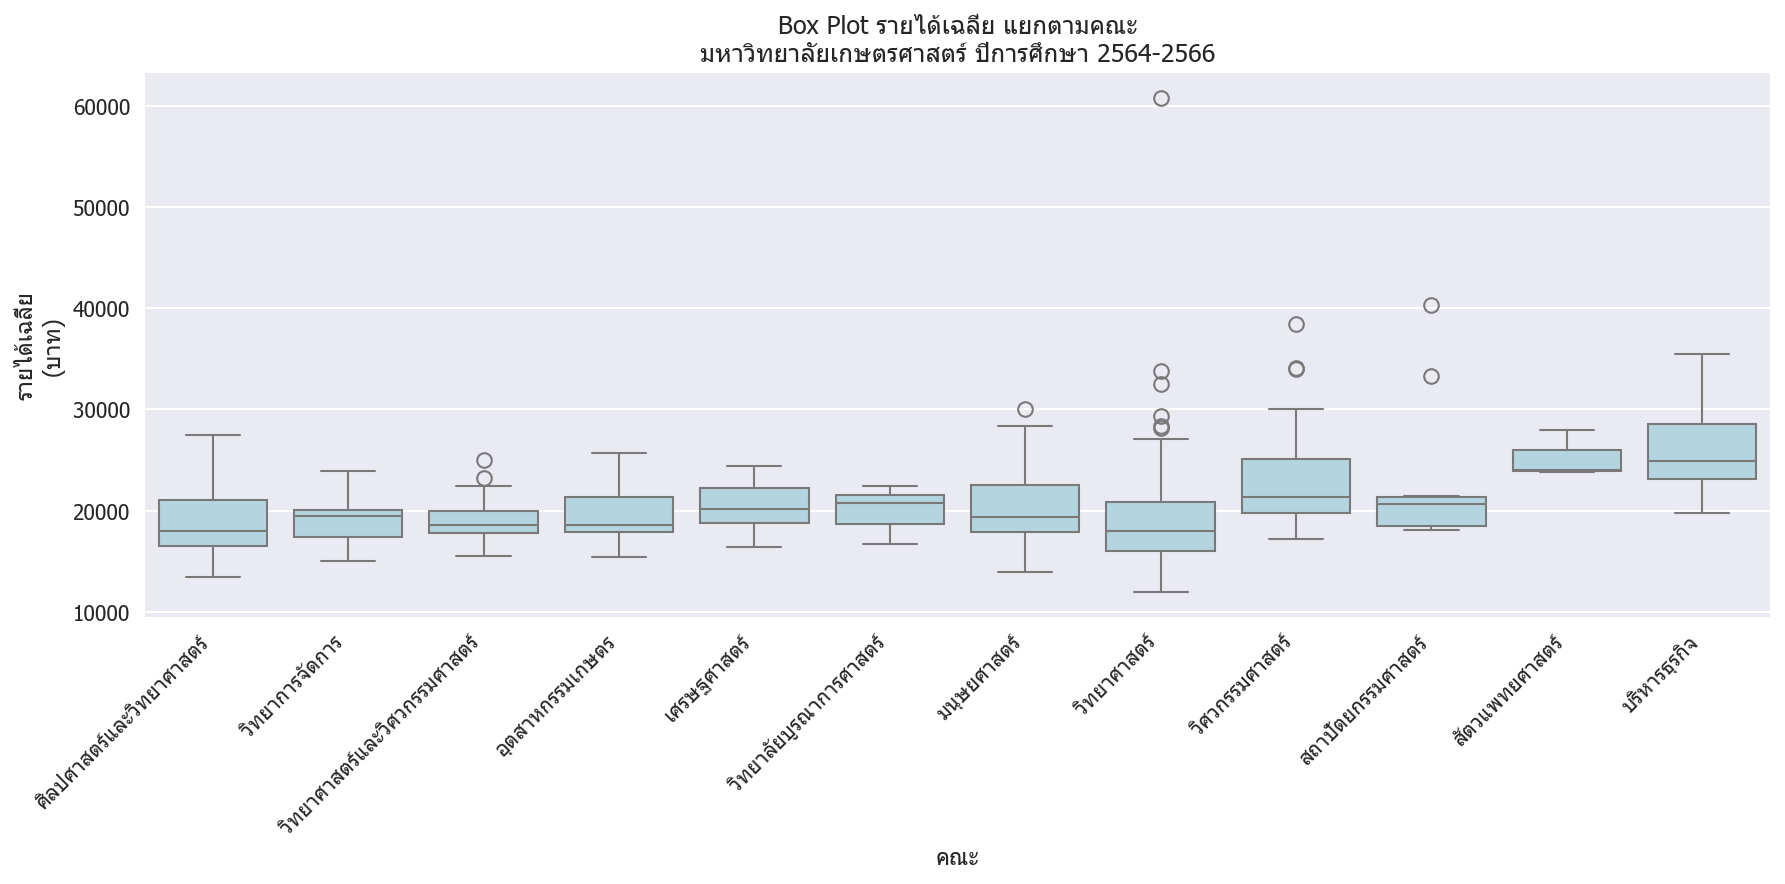

In [128]:
import seaborn as sns
import matplotlib.pyplot as plt

df = df_original.copy()
df = df[df['ระดับ'] == 'ป.ตรี']
df = df[df['นานาชาติ'] == False]
df = df[df["ปี"].isin([64, 65, 66])]
df = df[df["รายได้เฉลี่ย"] > 0]

df['รายได้เฉลี่ย_weight'] = df['ทำงาน'] * df['รายได้เฉลี่ย']
df_grouped = df.groupby('คณะ').agg(
          ผู้สำเร็จการศึกษา=('ผู้สำเร็จการศึกษา', 'sum'),
          รายได้เฉลี่ย_weight=('รายได้เฉลี่ย_weight', 'sum'),
          ทำงาน=('ทำงาน', 'sum'),
          งานตรงสาขา=('งานตรงสาขา', 'sum'),
      )
df_grouped['เปอร์เซ็นต์งานตรงสาขา'] = df_grouped['งานตรงสาขา'] / df_grouped['ทํางาน'] * 100
df_grouped['เปอร์เซ็นต์ผู้สำเร็จการศึกษา เทียบกับนักศึกษาทั้งหมด'] = df_grouped['ผู้สําเร็จการศึกษา'] / df_grouped['ผู้สําเร็จการศึกษา'].sum() * 100

df_grouped['รายได้เฉลี่ย'] = df_grouped['รายได้เฉลี่ย_weight'] / df_grouped['ทํางาน']

top_n = df_grouped.sort_values(by='รายได้เฉลี่ย').index[-12:]

df['คณะ'] = pd.Categorical(df['คณะ'], categories=top_n, ordered=True)

df = df.sort_values('คณะ')

plt.figure(figsize=(12,6), dpi=150)

sns.boxplot(data=df, x="คณะ", y="รายได้เฉลี่ย", color='lightblue', ax=plt.gca())

plt.xticks(rotation=45, ha="right")
plt.xlabel("คณะ")
plt.ylabel("รายได้เฉลี่ย\n(บาท)")
plt.title("Box Plot รายได้เฉลี่ย แยกตามคณะ\nมหาวิทยาลัยเกษตรศาสตร์ ปีการศึกษา 2564-2566")
plt.tight_layout()
plt.show()


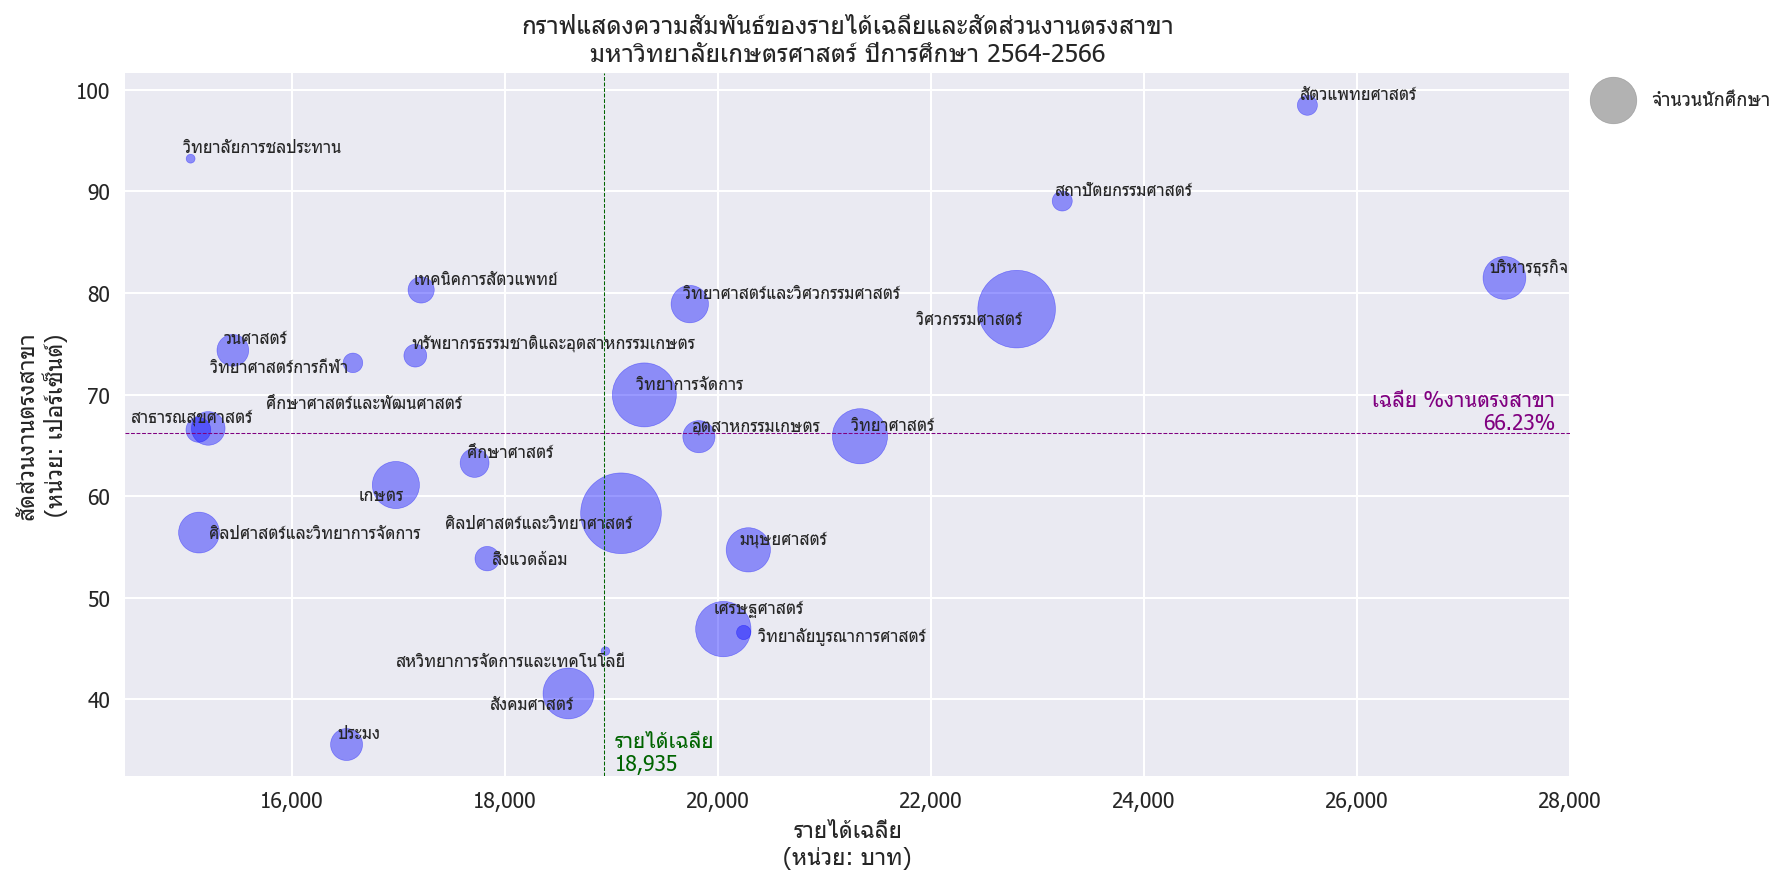

In [107]:
df = df_original.copy()

# filter
df = df[df['ระดับ'] == 'ป.ตรี']
df = df[df['นานาชาติ'] == False]
df = df[df["ปี"].isin([64, 65, 66])]

df['รายได้เฉลี่ย_weight'] = df['ทำงาน'] * df['รายได้เฉลี่ย']

df_grouped = df.groupby('คณะ').agg(
          ผู้สำเร็จการศึกษา=('ผู้สำเร็จการศึกษา', 'sum'),
          รายได้เฉลี่ย_weight=('รายได้เฉลี่ย_weight', 'sum'),
          ทำงาน=('ทำงาน', 'sum'),
          งานตรงสาขา=('งานตรงสาขา', 'sum'),
      )
df_grouped['เปอร์เซ็นต์งานตรงสาขา'] = df_grouped['งานตรงสาขา'] / df_grouped['ทํางาน'] * 100
df_grouped['เปอร์เซ็นต์ผู้สำเร็จการศึกษา เทียบกับนักศึกษาทั้งหมด'] = df_grouped['ผู้สําเร็จการศึกษา'] / df_grouped['ผู้สําเร็จการศึกษา'].sum() * 100

df_grouped['รายได้เฉลี่ย'] = df_grouped['รายได้เฉลี่ย_weight'] / df_grouped['ทํางาน']



# plot
plt.figure(figsize=(12,6), dpi=150)

ax = df_grouped.plot(kind='scatter',
                     x='รายได้เฉลี่ย',
                     y='เปอร์เซ็นต์งานตรงสาขา',
                     s=df_grouped['เปอร์เซ็นต์ผู้สำเร็จการศึกษา เทียบกับนักศึกษาทั้งหมด']*100,
                     color='blue',
                     ax=plt.gca(),
                     alpha=0.4
                   )

ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, p: format(int(x), ',')))

mean_salary = df_grouped['รายได้เฉลี่ย'].mean()
plt.axvline(mean_salary, color='darkgreen', linestyle='--', linewidth=0.5)
plt.text(mean_salary * 1.005, 33, f'รายได้เฉลี่ย\n{mean_salary:,.0f}', color='darkgreen', fontsize=10)

w = df_grouped['ทํางาน'].values
y_mean = np.average(df_grouped['เปอร์เซ็นต์งานตรงสาขา'].values, weights=w)
plt.axhline(y_mean, color='purple', linestyle='--', linewidth=0.5)
x_right = ax.get_xlim()[1]
plt.text(x_right * 0.995, y_mean,
         f'เฉลี่ย %งานตรงสาขา\n{y_mean:.2f}%',
         color='purple', fontsize=10, ha='right', va='bottom')

texts = []
for name, row in df_grouped.iterrows():
    texts.append(
        plt.text(row['รายได้เฉลี่ย'], row['เปอร์เซ็นต์งานตรงสาขา'], name, fontsize=8, ha='center')
    )
adjust_text(texts)

markers = []
markers.append(plt.scatter([], [], s=500, color='gray', alpha=0.6))

plt.legend([markers[0]], ['จำนวนนักศึกษา'], title="", scatterpoints=1,
           loc='upper right', fontsize=9, labelspacing=1.2, bbox_to_anchor=(1.15, 1), handletextpad=1)

plt.xlabel("รายได้เฉลี่ย\n(หน่วย: บาท)")
plt.ylabel("สัดส่วนงานตรงสาขา\n(หน่วย: เปอร์เซ็นต์)")
plt.title("กราฟแสดงความสัมพันธ์ของรายได้เฉลี่ยและสัดส่วนงานตรงสาขา\nมหาวิทยาลัยเกษตรศาสตร์ ปีการศึกษา 2564-2566")
plt.tight_layout()
plt.show()

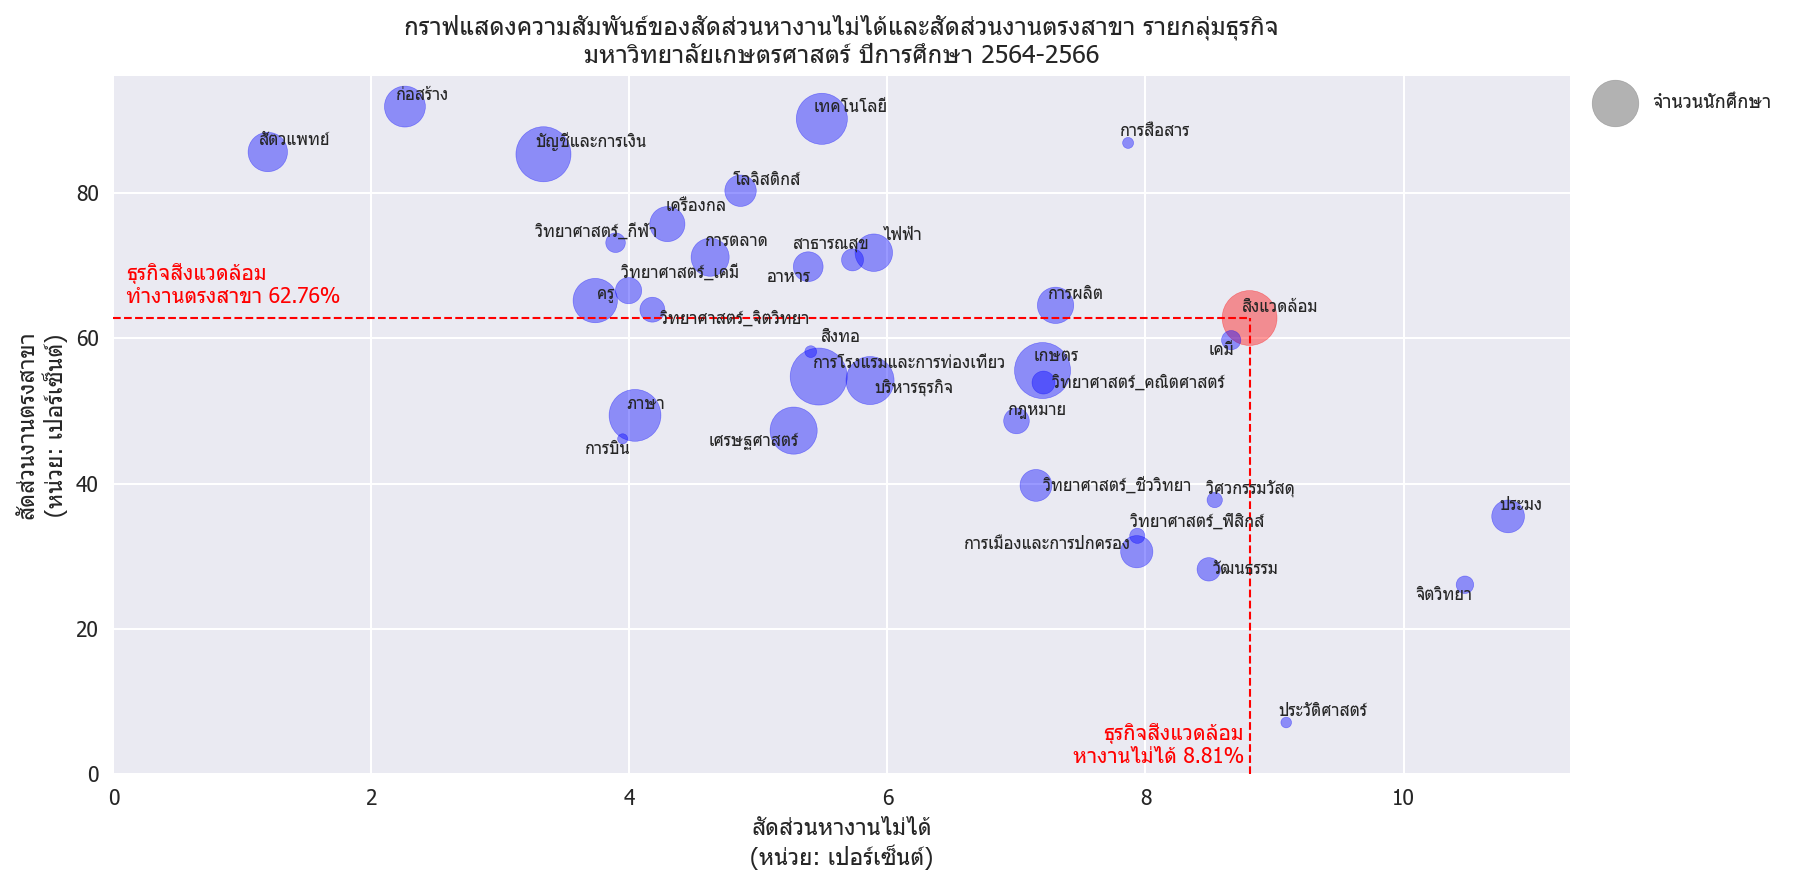

In [108]:
df = df_original.copy()
df = df[df['ระดับ'] == 'ป.ตรี']
df = df[df['นานาชาติ'] == False]
df = df[df["ปี"].isin([64, 65, 66])]


df['รายได้เฉลี่ย_weight'] = df['ทำงาน'] * df['รายได้เฉลี่ย']
df["คณะ|สาขา"] = df['คณะ'] + '|' + df['สาขา']
df = df.merge(
    df_business,
    how="inner",
    left_on="คณะ|สาขา",
    right_on="คณะ|สาขา"
)

g_column = 'กลุ่มธุรกิจ'
df_grouped = df.groupby(g_column).agg(
          ทำงาน=('ทำงาน', 'sum'),
          ไม่ทำงาน=('ไม่ทำงาน', 'sum'),
          ผู้สำเร็จการศึกษา=('ผู้สำเร็จการศึกษา', 'sum'),
          หางานไม่ได้=('หางานไม่ได้', 'sum'),
          งานตรงสาขา=('งานตรงสาขา', 'sum'),
          รายได้เฉลี่ย_weight=('รายได้เฉลี่ย_weight', 'sum'),
      )
df_grouped['รายได้เฉลี่ย'] = df_grouped['รายได้เฉลี่ย_weight'] / df_grouped['ทํางาน']
df_grouped['เปอร์เซ็นต์งานตรงสาขา'] = df_grouped['งานตรงสาขา'] / df_grouped['ทํางาน'] * 100
df_grouped['ทำงาน_ไม่ทำงาน'] = df_grouped['ทํางาน'] + df_grouped['ไม่ทํางาน']
df_grouped['เปอร์เซ็นต์หางานไม่ได้'] = df_grouped['หางานไม่ได้'] / df_grouped['ทำงาน_ไม่ทำงาน'] * 100
df_grouped['เปอร์เซ็นต์ผู้สำเร็จการศึกษา เทียบกับนักศึกษาทั้งหมด'] = df_grouped['ผู้สําเร็จการศึกษา'] / df_grouped['ผู้สําเร็จการศึกษา'].sum() * 100
df_grouped.sort_values(by='เปอร์เซ็นต์หางานไม่ได้', inplace=True, ascending=False)


plt.figure(figsize=(12,6), dpi=150)

y_column = 'เปอร์เซ็นต์งานตรงสาขา'
x_column = 'เปอร์เซ็นต์หางานไม่ได้'
s_column = 'เปอร์เซ็นต์ผู้สำเร็จการศึกษา เทียบกับนักศึกษาทั้งหมด'


colors = ['blue'] * len(df_grouped)

mask = df_grouped[x_column] >= 8
if mask.any():
    idx_max = df_grouped.loc[mask, s_column].idxmax()
    colors[df_grouped.index.get_loc(idx_max)] = 'red'

ax = df_grouped.plot(kind='scatter',
                     x=x_column,
                     y=y_column,
                     s=df_grouped[s_column]*100,
                     color=colors,
                     ax=plt.gca(),
                     alpha=0.4
                   )

ax.set_xlim(0)
ax.set_ylim(0)

# --- วาดเส้นจากจุดแดงไปยังแกน ---
if mask.any():
    x_val = df_grouped.loc[idx_max, x_column]
    y_val = df_grouped.loc[idx_max, y_column]

    # เส้นแนวตั้งถึงแกน X
    ax.plot([x_val, x_val], [0, y_val], color='red', linestyle='--', linewidth=1)
    plt.text(x_val * 0.995, 1,
            f'ธุรกิจ{idx_max}\nหางานไม่ได้ {x_val:.2f}%',
            color='red', fontsize=10, ha='right', va='bottom')

    # เส้นแนวนอนถึงแกน Y
    ax.plot([0, x_val], [y_val, y_val], color='red', linestyle='--', linewidth=1)
    plt.text(0.1, y_val * 1.12,
            f'ธุรกิจ{idx_max}\nทำงานตรงสาขา {y_val:.2f}%',
            color='red', fontsize=10, ha='left', va='top')


# เพิ่ม label ชื่อกลุ่มธุรกิจ + adjust_text
texts = []
for name, row in df_grouped.iterrows():
    texts.append(
        plt.text(row[x_column], row[y_column], name, fontsize=8, ha='center')
    )
adjust_text(texts)

markers = []
markers.append(plt.scatter([], [], s=500, color='gray', alpha=0.6))

plt.legend([markers[0]], ['จำนวนนักศึกษา'], title="", scatterpoints=1,
           loc='upper right', fontsize=9, labelspacing=1.2, bbox_to_anchor=(1.15, 1), handletextpad=1)

plt.xlabel("สัดส่วนหางานไม่ได้\n(หน่วย: เปอร์เซ็นต์)")
plt.ylabel("สัดส่วนงานตรงสาขา\n(หน่วย: เปอร์เซ็นต์)")
plt.title("กราฟแสดงความสัมพันธ์ของสัดส่วนหางานไม่ได้และสัดส่วนงานตรงสาขา รายกลุ่มธุรกิจ\nมหาวิทยาลัยเกษตรศาสตร์ ปีการศึกษา 2564-2566")
plt.tight_layout()
plt.show()

In [125]:
df = df_original.copy()
df = df[df['ระดับ'] == 'ป.ตรี']
df = df[df['นานาชาติ'] == False]
df = df[df["ปี"].isin([64, 65, 66])]
df = df[df["รายได้เฉลี่ย"] > 0]

df["คณะ|สาขา"] = df['คณะ'] + '|' + df['สาขา']
df = df.merge(
    df_business,
    how="inner",
    left_on="คณะ|สาขา",
    right_on="คณะ|สาขา"
)

# สรุปตัวเลขงานต่างๆ ต่อกลุ่มธุรกิจ
work_summary = (
    df.groupby('กลุ่มธุรกิจ')[['งานตรงสาขา', 'งานไม่ตรงสาขา', 'หางานไม่ได้', 'ผู้บันทึกข้อมูล']]
    .sum()
    .reset_index()
)
work_summary['รวมมีงานทำ'] = work_summary['งานตรงสาขา'] + work_summary['งานไม่ตรงสาขา']
work_summary['สัดส่วนงานตรงสาขา'] = (work_summary['งานตรงสาขา'] / work_summary['รวมมีงานทำ']).fillna(0)
work_summary['สัดส่วนหางานไม่ได้'] = (work_summary['หางานไม่ได้'] / work_summary['ผู้บันทึกข้อมูล']).fillna(0)

# ตารางสรุปผู้สำเร็จการศึกษา
summary_table = (
    df.groupby('กลุ่มธุรกิจ')['ผู้สำเร็จการศึกษา']
    .sum()
    .reset_index()
    .sort_values(by='ผู้สำเร็จการศึกษา', ascending=False)
)

# รวมตารางเข้าด้วยกัน
summary_table = pd.merge(
    summary_table,
    work_summary[['กลุ่มธุรกิจ', 'สัดส่วนงานตรงสาขา', 'สัดส่วนหางานไม่ได้']],
    on='กลุ่มธุรกิจ',
    how='left'
)

# คำนวณสัดส่วนผู้สำเร็จการศึกษา (เป็น % string)
total = summary_table['ผู้สำเร็จการศึกษา'].sum()
summary_table['สัดส่วนผู้สำเร็จการศึกษา'] = (
    summary_table['ผู้สำเร็จการศึกษา'] / total * 100
).map('{:.2f}%'.format)

# คัด Top 5 กลุ่มธุรกิจที่หางานไม่ได้สูงสุด
summary_table_top5 = (
    summary_table.sort_values(by='สัดส่วนหางานไม่ได้', ascending=False)
    .head(5)
    .copy()
)
summary_table_top5.reset_index(drop=True, inplace=True)

# ฟอร์แมตคอลัมน์สัดส่วนงานตรงสาขา & หางานไม่ได้เป็น %
summary_table_top5['สัดส่วนงานตรงสาขา'] = summary_table_top5['สัดส่วนงานตรงสาขา'].map('{:.2%}'.format)
summary_table_top5['สัดส่วนหางานไม่ได้'] = summary_table_top5['สัดส่วนหางานไม่ได้'].map('{:.2%}'.format)

# เหลือเฉพาะคอลัมน์ที่ต้องการ (ตัดผลรวมผู้สำเร็จการศึกษาออก)
summary_table_top5 = summary_table_top5[
    ['กลุ่มธุรกิจ', 'สัดส่วนผู้สำเร็จการศึกษา',
     'สัดส่วนงานตรงสาขา', 'สัดส่วนหางานไม่ได้']
]

def stripe_rows(row):
    # สลับสีตามแถว
    color = '#f2f2f2' if row.name % 2 == 0 else 'white'
    return [f'background-color: {color}; color: black;' for _ in row]

# ไฮไลท์แถว "สิ่งแวดล้อม"
def highlight_env(row):
    return ['background-color: yellow' if row['กลุ่มธุรกิจ'] == 'สิ่งแวดล้อม' else '' for _ in row]

custom_styles = [
    dict(selector="th", props=[("background-color", "white"),("color", "black"),('border-bottom', '1px solid #a2a2a2')]),
]

# แสดงตาราง (ซ่อน index)
summary_table_top5.style.set_table_styles(custom_styles) \
    .apply(stripe_rows, axis=1) \
    .apply(highlight_env, axis=1).hide(axis="index")

กลุ่มธุรกิจ,สัดส่วนผู้สำเร็จการศึกษา,สัดส่วนงานตรงสาขา,สัดส่วนหางานไม่ได้
ประมง,2.47%,35.48%,10.81%
จิตวิทยา,0.71%,26.09%,9.36%
ประวัติศาสตร์,0.26%,7.14%,9.09%
สิ่งแวดล้อม,6.93%,62.76%,8.62%
เคมี,0.86%,59.72%,8.33%


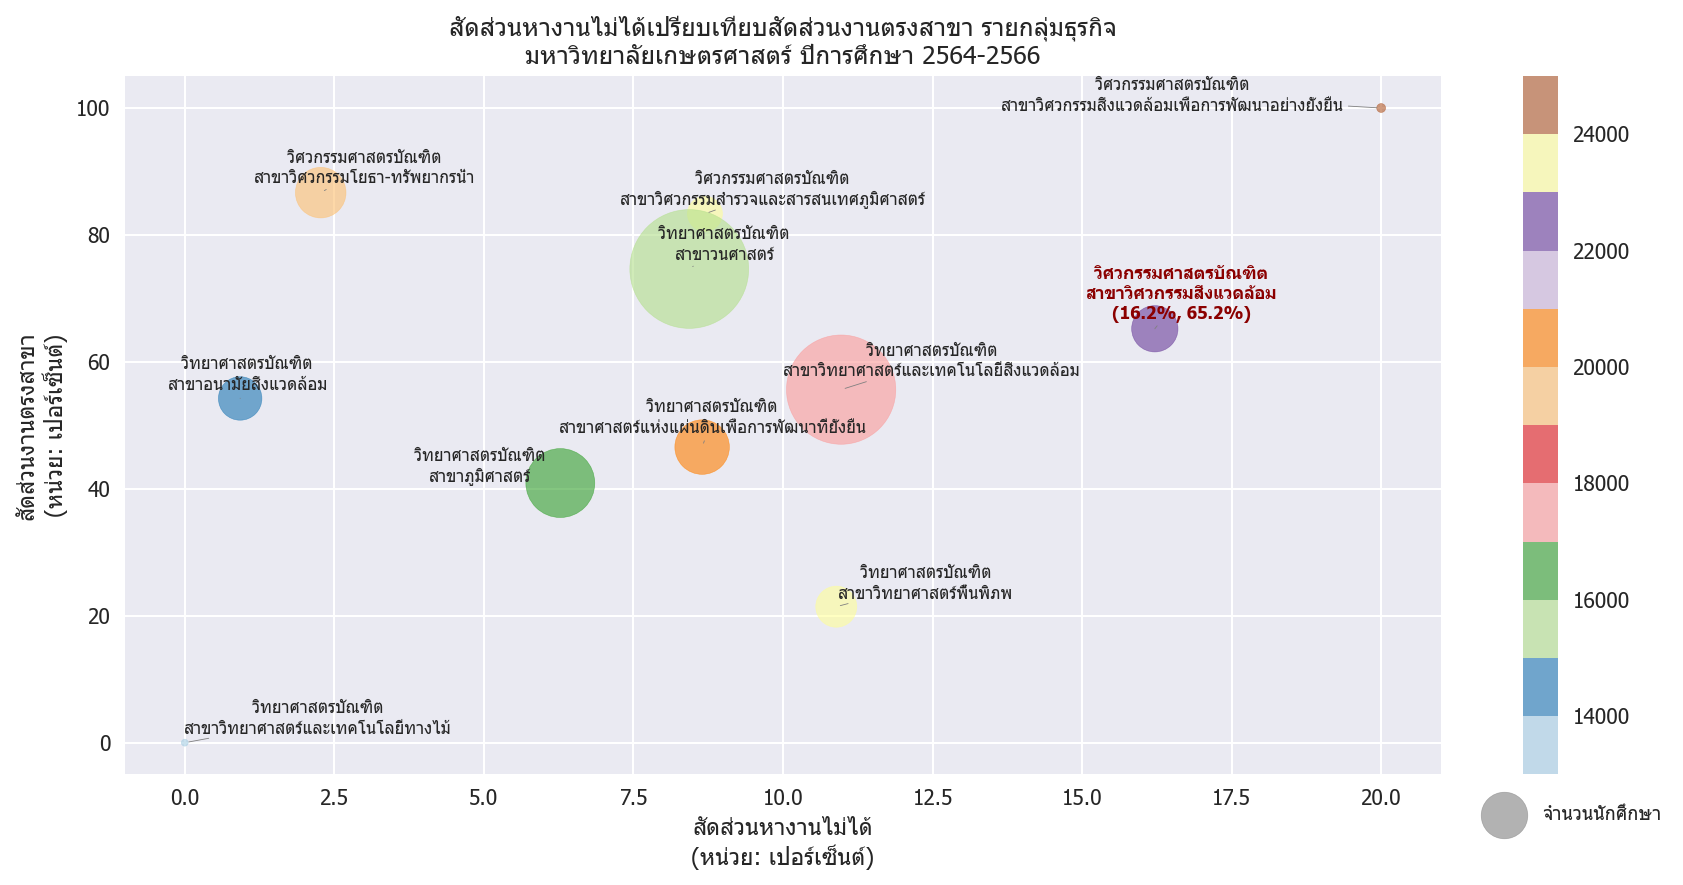

In [110]:
df = df_original.copy()
df = df[df['ระดับ'] == 'ป.ตรี']
df = df[df['นานาชาติ'] == False]
df = df[df["ปี"].isin([64, 65, 66])]

df['รายได้เฉลี่ย_weight'] = df['ทำงาน'] * df['รายได้เฉลี่ย']
df["คณะ|สาขา"] = df['คณะ'] + '|' + df['สาขา']
df = df.merge(
    df_business,
    how="inner",
    left_on="คณะ|สาขา",
    right_on="คณะ|สาขา"
)

df = df[df['กลุ่มธุรกิจ'] == 'สิ่งแวดล้อม']

df['สาขา'] = df['สาขา'].str.replace(' ', '\n')
g_column = 'สาขา'
df_grouped = df.groupby(g_column).agg(
          ทำงาน=('ทำงาน', 'sum'),
          ไม่ทำงาน=('ไม่ทำงาน', 'sum'),
          ผู้สำเร็จการศึกษา=('ผู้สำเร็จการศึกษา', 'sum'),
          หางานไม่ได้=('หางานไม่ได้', 'sum'),
          งานตรงสาขา=('งานตรงสาขา', 'sum'),
          รายได้เฉลี่ย_weight=('รายได้เฉลี่ย_weight', 'sum'),
      )
df_grouped['รายได้เฉลี่ย'] = df_grouped['รายได้เฉลี่ย_weight'] / df_grouped['ทํางาน']
df_grouped['เปอร์เซ็นต์งานตรงสาขา'] = df_grouped['งานตรงสาขา'] / df_grouped['ทํางาน'] * 100
df_grouped['ทำงาน_ไม่ทำงาน'] = df_grouped['ทํางาน'] + df_grouped['ไม่ทํางาน']
df_grouped['เปอร์เซ็นต์หางานไม่ได้'] = df_grouped['หางานไม่ได้'] / df_grouped['ทำงาน_ไม่ทำงาน'] * 100
df_grouped['เปอร์เซ็นต์ผู้สำเร็จการศึกษา เทียบกับนักศึกษาทั้งหมด'] = df_grouped['ผู้สําเร็จการศึกษา'] / df_grouped['ผู้สําเร็จการศึกษา'].sum() * 100
df_grouped.sort_values(by='เปอร์เซ็นต์หางานไม่ได้', inplace=True, ascending=False)

plt.figure(figsize=(12,6), dpi=150)

y_column = 'เปอร์เซ็นต์งานตรงสาขา'
x_column = 'เปอร์เซ็นต์หางานไม่ได้'
s_column = 'เปอร์เซ็นต์ผู้สำเร็จการศึกษา เทียบกับนักศึกษาทั้งหมด'

ax = df_grouped.plot(kind='scatter',
                     x=x_column,
                     y=y_column,
                     s=df_grouped[s_column]*100,
                     c=df_grouped['รายได้เฉลี่ย'],
                     cmap='Paired',
                     ax=plt.gca(),
                     alpha=0.6
                   )


target_keyword = "วิศวกรรมสิ่งแวดล้อม"
exclude_keyword = "ยั่งยืน"
texts = []
for name, row in df_grouped.iterrows():
    x, y = row[x_column], row[y_column]
    if np.isfinite(x) and np.isfinite(y):
        name_clean = name.replace('\n', '')
        if (target_keyword in name_clean) and (exclude_keyword not in name_clean):
            label = f"{name}\n({x:.1f}%, {y:.1f}%)"
            texts.append(plt.text(x, y, label, fontsize=8, ha='center', va='bottom',
                                  color='#8B0000', fontweight='bold'))
        else:
            texts.append(plt.text(x, y, name, fontsize=8, ha='center', va='bottom'))


adjust_text(texts, ax=ax, arrowprops=dict(arrowstyle='-', lw=0.4, color='gray'))

markers = []
markers.append(plt.scatter([], [], s=5*100, color='gray', alpha=0.6))

plt.legend([markers[0]], ['จำนวนนักศึกษา'], title="", scatterpoints=1,
           loc='upper right', fontsize=9, labelspacing=1.2, bbox_to_anchor=(1.18, -0.02), handletextpad=1)

plt.xlabel("สัดส่วนหางานไม่ได้\n(หน่วย: เปอร์เซ็นต์)")
plt.ylabel("สัดส่วนงานตรงสาขา\n(หน่วย: เปอร์เซ็นต์)")
plt.title("สัดส่วนหางานไม่ได้เปรียบเทียบสัดส่วนงานตรงสาขา รายกลุ่มธุรกิจ\nมหาวิทยาลัยเกษตรศาสตร์ ปีการศึกษา 2564-2566")
plt.tight_layout()
plt.show()

# วิศวกรรมสิ่งแวดล้อม มหาลัยอื่น

In [ ]:
raw_url = 'https://github.com/nopchok/mini-project/raw/refs/heads/main/data/%E0%B8%A7%E0%B8%B4%E0%B8%A8%E0%B8%A7%E0%B8%81%E0%B8%A3%E0%B8%A3%E0%B8%A1%E0%B8%AA%E0%B8%B4%E0%B9%88%E0%B8%87%E0%B9%81%E0%B8%A7%E0%B8%94%E0%B8%A5%E0%B9%89%E0%B8%AD%E0%B8%A1%20%E0%B8%A1%E0%B8%AB%E0%B8%B2%E0%B8%A5%E0%B8%B1%E0%B8%A2%E0%B8%AD%E0%B8%B7%E0%B9%88%E0%B8%99.xlsx'
df_env_eng = pd.read_excel(raw_url)
df_env_eng

,ปี,มหาวิทยาลัย,คณะ,สาขา,มีงานทำแล้ว,ยังไม่ได้ทำงาน,ศึกษาต่อ,เกณฑ์ทหาร,อุปสมบท,%มีงานทำ,%ไม่ได้งานทำ,เงินเดือนเฉลี่ย
0,2566,มหาวิทยาลัยขอนแก่น,วิศวกรรมศาสตร์,วิศวกรรมสิ่งแวดล้อม,12,14,4,NaN,NaN,0.400000,0.460526,NaN
1,2565,มหาวิทยาลัยเทคโนโลยีสุรนารี,วิศวกรรมศาสตร์,วิศวกรรมสิ่งแวดล้อม,58,5,3,0.0,0.0,0.878788,0.074762,17807.71
2,2564,มหาวิทยาลัยเทคโนโลยีสุรนารี,วิศวกรรมศาสตร์,วิศวกรรมสิ่งแวดล้อม,60,13,2,1.0,0.0,0.789474,0.169294,17479.25
3,2563,มหาวิทยาลัยเทคโนโลยีสุรนารี,วิศวกรรมศาสตร์,วิศวกรรมสิ่งแวดล้อม,60,25,4,0.0,0.0,0.674157,0.278787,18816.67
4,2562,มหาวิทยาลัยเทคโนโลยีสุรนารี,วิศวกรรมศาสตร์,วิศวกรรมสิ่งแวดล้อม,49,14,5,3.0,1.0,0.680556,0.192624,17152.78
5,2561,มหาวิทยาลัยเทคโนโลยีสุรนารี,วิศวกรรมศาสตร์,วิศวกรรมสิ่งแวดล้อม,43,4,4,0.0,1.0,0.826923,0.075719,19052.86
6,2560,มหาวิทยาลัยเทคโนโลยีสุรนารี,วิศวกรรมศาสตร์,วิศวกรรมสิ่งแวดล้อม,53,19,3,0.0,0.0,0.706667,0.250969,18738.89
7,2562,มหาวิทยาลัยเชียงใหม่,วิศวกรรมศาสตร์,วิศวกรรมสิ่งแวดล้อม,11,1,6,0.0,0.0,0.611111,0.053731,18154.55
8,2561,มหาวิทยาลัยเชียงใหม่,วิศวกรรมศาสตร์,วิศวกรรมสิ่งแวดล้อม,37,15,3,0.0,0.0,0.672727,0.269432,18831.82
9,2564,มหาวิทยาลัยนเรศวร,วิศวกรรมศาสตร์,วิศวกรรมสิ่งแวดล้อม,12,12,1,1.0,0.0,0.461538,0.453488,17953.46


In [112]:
df_env_eng_group = df_env_eng.copy()
df_env_eng_group = df_env_eng_group[ df_env_eng_group['มหาวิทยาลัย'].isin(['มหาวิทยาลัยนเรศวร', 'มหาวิทยาลัยเทคโนโลยีสุรนารี']) ]
df_env_eng_group = df_env_eng_group.groupby(['มหาวิทยาลัย', 'ปี']).agg(
    ไม่ได้งานทำ=('%ไม่ได้งานทำ', 'sum')
)
df_env_eng_group.reset_index(inplace=True)
df_env_eng_group['ไม่ได้งานทํา'] = df_env_eng_group['ไม่ได้งานทํา'] * 100
df_env_eng_group

,มหาวิทยาลัย,ปี,ไม่ได้งานทํา
0,มหาวิทยาลัยนเรศวร,2562,35.562310
1,มหาวิทยาลัยนเรศวร,2563,59.945504
2,มหาวิทยาลัยนเรศวร,2564,45.348837
3,มหาวิทยาลัยเทคโนโลยีสุรนารี,2560,25.096865
4,มหาวิทยาลัยเทคโนโลยีสุรนารี,2561,7.571897
5,มหาวิทยาลัยเทคโนโลยีสุรนารี,2562,19.262373
6,มหาวิทยาลัยเทคโนโลยีสุรนารี,2563,27.878712
7,มหาวิทยาลัยเทคโนโลยีสุรนารี,2564,16.929404
8,มหาวิทยาลัยเทคโนโลยีสุรนารี,2565,7.476212


In [113]:
df = df_original.copy()
df = df[df['สาขา'] == 'วิศวกรรมศาสตรบัณฑิต สาขาวิศวกรรมสิ่งแวดล้อม'][['ปี', 'ผู้บันทึกข้อมูล', 'ไม่ทำงาน']]
df['ปี'] = df['ปี'] + 2500
df['ไม่ได้งานทํา'] = df['ไม่ทำงาน'] * 100 / df['ผู้บันทึกข้อมูล']
df['มหาวิทยาลัย'] = 'มหาวิทยาลัยเกษตรศาสตร์'
df = df[['มหาวิทยาลัย', 'ปี', 'ไม่ได้งานทํา']]
df

,มหาวิทยาลัย,ปี,ไม่ได้งานทํา
53,มหาวิทยาลัยเกษตรศาสตร์,2557,20.000000
244,มหาวิทยาลัยเกษตรศาสตร์,2558,57.692308
445,มหาวิทยาลัยเกษตรศาสตร์,2559,41.666667
666,มหาวิทยาลัยเกษตรศาสตร์,2560,60.000000
838,มหาวิทยาลัยเกษตรศาสตร์,2561,74.193548
1018,มหาวิทยาลัยเกษตรศาสตร์,2562,70.833333
1199,มหาวิทยาลัยเกษตรศาสตร์,2563,74.074074
1386,มหาวิทยาลัยเกษตรศาสตร์,2564,86.842105
1573,มหาวิทยาลัยเกษตรศาสตร์,2565,67.741935
1762,มหาวิทยาลัยเกษตรศาสตร์,2566,73.913043


In [114]:
df_env_all = pd.concat([df_env_eng_group, df], ignore_index=True)
df_env_all = df_env_all[ df_env_all['ปี'].isin([2566, 2565, 2564, 2563]) ]
df_env_all

,มหาวิทยาลัย,ปี,ไม่ได้งานทํา
1,มหาวิทยาลัยนเรศวร,2563,59.945504
2,มหาวิทยาลัยนเรศวร,2564,45.348837
6,มหาวิทยาลัยเทคโนโลยีสุรนารี,2563,27.878712
7,มหาวิทยาลัยเทคโนโลยีสุรนารี,2564,16.929404
8,มหาวิทยาลัยเทคโนโลยีสุรนารี,2565,7.476212
15,มหาวิทยาลัยเกษตรศาสตร์,2563,74.074074
16,มหาวิทยาลัยเกษตรศาสตร์,2564,86.842105
17,มหาวิทยาลัยเกษตรศาสตร์,2565,67.741935
18,มหาวิทยาลัยเกษตรศาสตร์,2566,73.913043


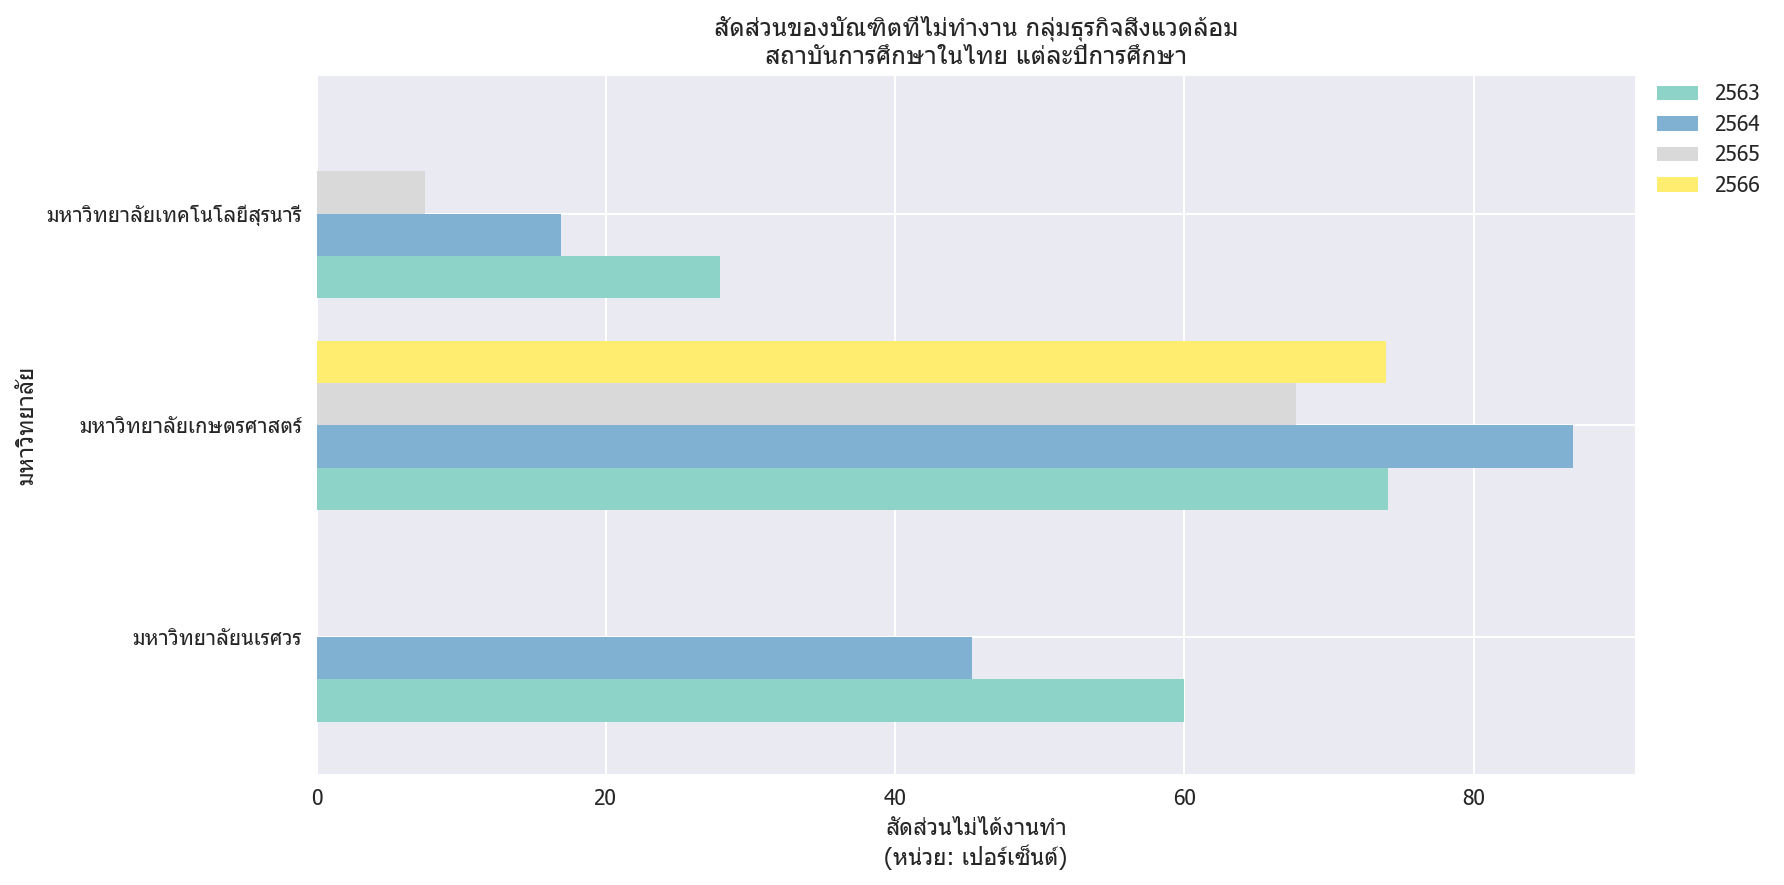

In [115]:
# pivot เพื่อให้อยู่ในรูป wide
df_pivot = df_env_all.pivot(index="มหาวิทยาลัย", columns="ปี", values="ไม่ได้งานทํา")

plt.figure(figsize=(12,6), dpi=150)
ax = df_pivot.plot(kind="barh", width=0.8, colormap='Set3', ax=plt.gca())

# ย้าย legend ออกด้านข้างขวา
plt.legend(title=None)
ax.legend(
    bbox_to_anchor=(1.01, 1),
    loc='upper left',
    borderaxespad=0
)

plt.xlabel("สัดส่วนไม่ได้งานทำ\n(หน่วย: เปอร์เซ็นต์)")
plt.ylabel("มหาวิทยาลัย")
plt.title("สัดส่วนของบัณฑิตที่ไม่ทำงาน กลุ่มธุรกิจสิ่งแวดล้อม\nสถาบันการศึกษาในไทย แต่ละปีการศึกษา")
plt.tight_layout()
plt.show()

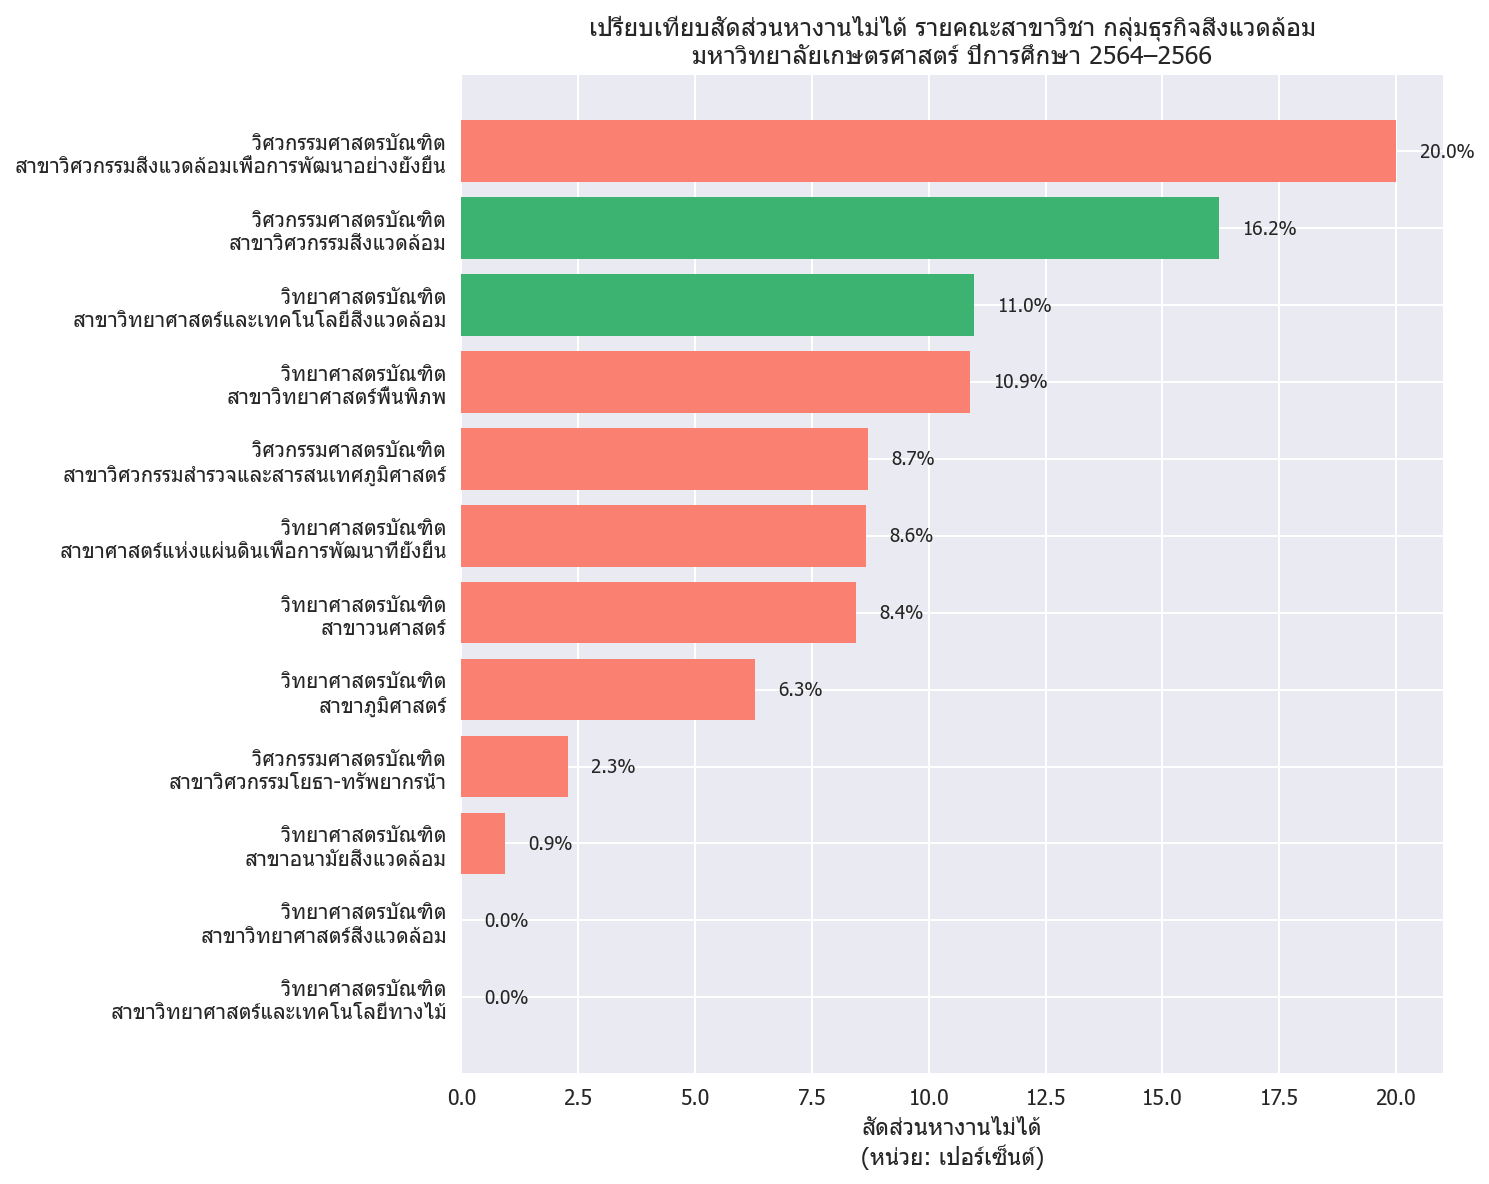

In [116]:
df = df_original.copy()
df = df[df['ระดับ'] == 'ป.ตรี']
df = df[df['นานาชาติ'] == False]
df = df[df["ปี"].isin([64, 65, 66])]


df['รายได้เฉลี่ย_weight'] = df['ทำงาน'] * df['รายได้เฉลี่ย']
df["คณะ|สาขา"] = df['คณะ'] + '|' + df['สาขา']
df = df.merge(
    df_business,
    how="inner",
    left_on="คณะ|สาขา",
    right_on="คณะ|สาขา"
)

df = df[df['กลุ่มธุรกิจ'] == 'สิ่งแวดล้อม']

df['สาขา'] = df['สาขา'].str.replace(' ', '\n')
g_column = 'สาขา'
df_grouped = df.groupby(g_column).agg(
          ทำงาน=('ทำงาน', 'sum'),
          ไม่ทำงาน=('ไม่ทำงาน', 'sum'),
          ผู้สำเร็จการศึกษา=('ผู้สำเร็จการศึกษา', 'sum'),
          หางานไม่ได้=('หางานไม่ได้', 'sum'),
          งานตรงสาขา=('งานตรงสาขา', 'sum'),
          รายได้เฉลี่ย_weight=('รายได้เฉลี่ย_weight', 'sum'),
      )
df_grouped['รายได้เฉลี่ย'] = df_grouped['รายได้เฉลี่ย_weight'] / df_grouped['ทํางาน']
df_grouped['เปอร์เซ็นต์งานตรงสาขา'] = df_grouped['งานตรงสาขา'] / df_grouped['ทํางาน'] * 100
df_grouped['ทำงาน_ไม่ทำงาน'] = df_grouped['ทํางาน'] + df_grouped['ไม่ทํางาน']
df_grouped['เปอร์เซ็นต์หางานไม่ได้'] = df_grouped['หางานไม่ได้'] / df_grouped['ทำงาน_ไม่ทำงาน'] * 100
df_grouped['เปอร์เซ็นต์ผู้สำเร็จการศึกษา เทียบกับนักศึกษาทั้งหมด'] = df_grouped['ผู้สําเร็จการศึกษา'] / df_grouped['ผู้สําเร็จการศึกษา'].sum() * 100

# เรียงตามเปอร์เซ็นต์หางานไม่ได้
df_sorted = df_grouped.sort_values(by='เปอร์เซ็นต์หางานไม่ได้', ascending=False)
colors = ['salmon'] * len(df_sorted)

# เปลี่ยนสีอันดับที่ 2 และ 3 (index 1 และ 2)
colors[1] = 'mediumseagreen'
colors[2] = 'mediumseagreen'

# สร้างกราฟ bar chart แนวนอน
plt.figure(figsize=(10, 8), dpi=150)
bars = plt.barh(df_sorted.index, df_sorted['เปอร์เซ็นต์หางานไม่ได้'], color=colors)
plt.xlabel('สัดส่วนหางานไม่ได้\n(หน่วย: เปอร์เซ็นต์)')
plt.title('เปรียบเทียบสัดส่วนหางานไม่ได้ รายคณะสาขาวิชา กลุ่มธุรกิจสิ่งแวดล้อม\nมหาวิทยาลัยเกษตรศาสตร์ ปีการศึกษา 2564–2566')
plt.gca().invert_yaxis()


for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.5, bar.get_y() + bar.get_height()/2,
             f'{width:.1f}%', va='center', fontsize=9)

plt.tight_layout()
plt.show()


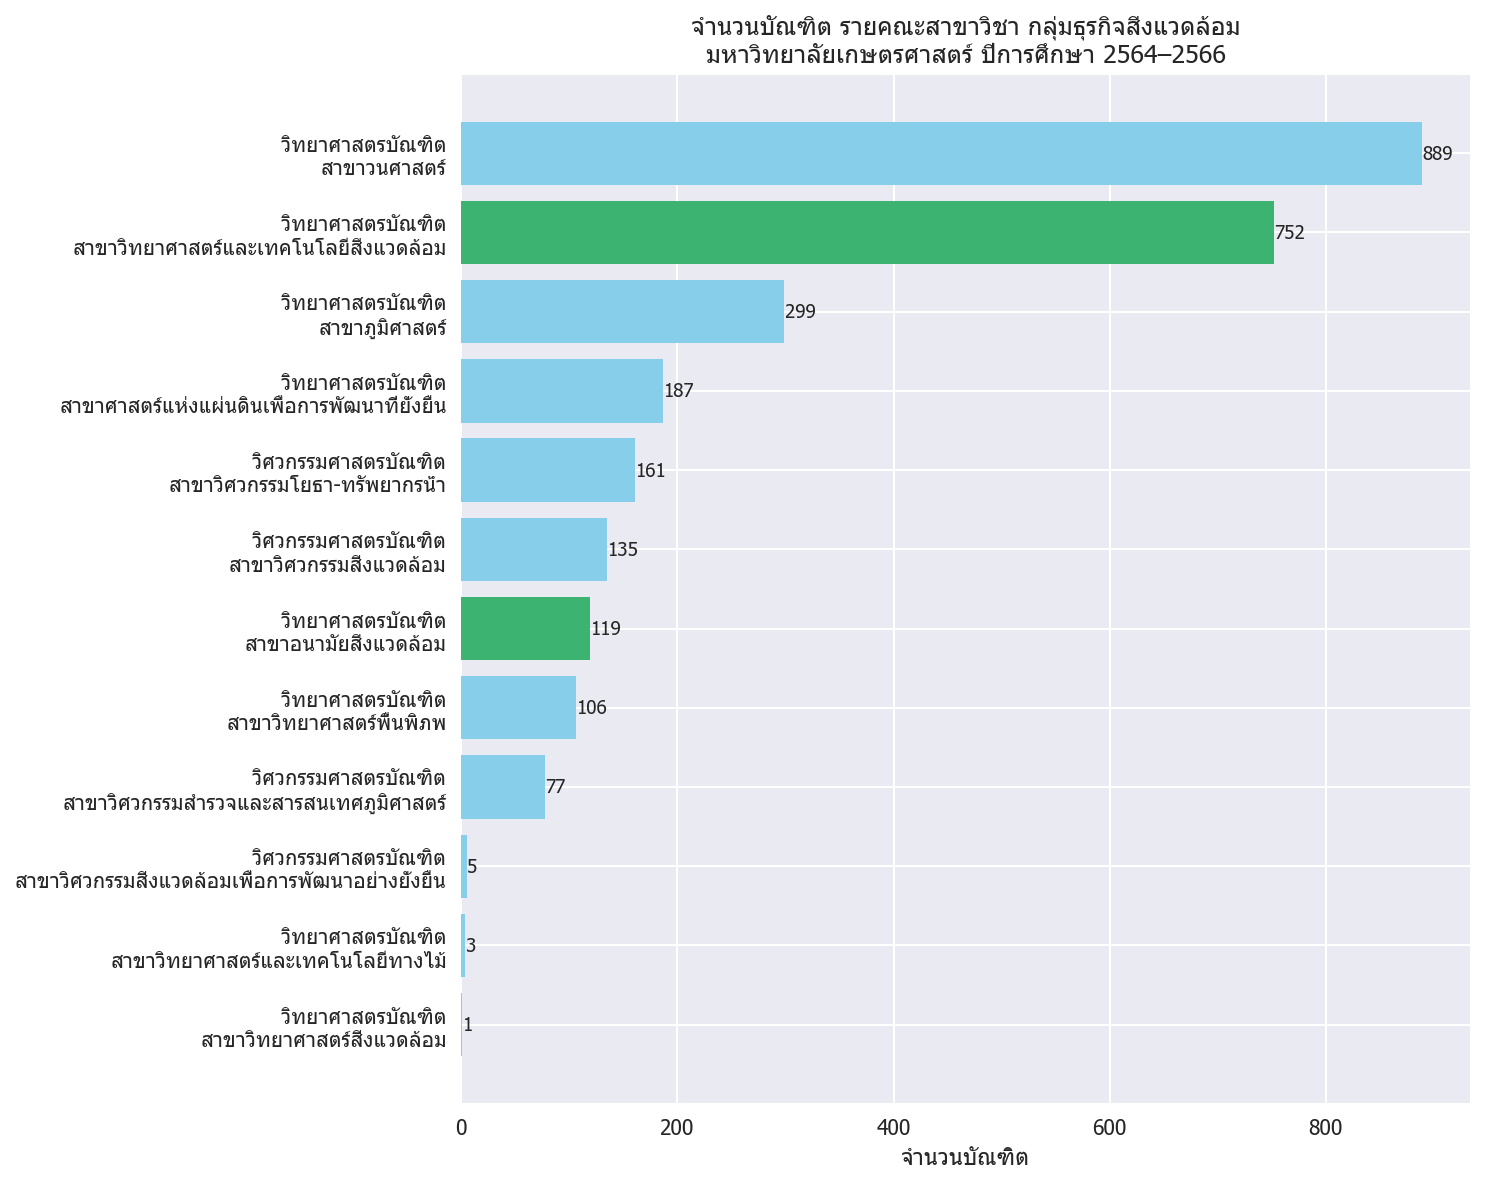

In [117]:
df = df_original.copy()
df = df[df['ระดับ'] == 'ป.ตรี']
df = df[df['นานาชาติ'] == False]
df = df[df["ปี"].isin([64, 65, 66])]


df['รายได้เฉลี่ย_weight'] = df['ทำงาน'] * df['รายได้เฉลี่ย']
df["คณะ|สาขา"] = df['คณะ'] + '|' + df['สาขา']
df = df.merge(
    df_business,
    how="inner",
    left_on="คณะ|สาขา",
    right_on="คณะ|สาขา"
)

df = df[df['กลุ่มธุรกิจ'] == 'สิ่งแวดล้อม']

df['สาขา'] = df['สาขา'].str.replace(' ', '\n')
g_column = 'สาขา'
df_grouped = df.groupby(g_column).agg(
          ทำงาน=('ทำงาน', 'sum'),
          ไม่ทำงาน=('ไม่ทำงาน', 'sum'),
          ผู้สำเร็จการศึกษา=('ผู้สำเร็จการศึกษา', 'sum'),
          หางานไม่ได้=('หางานไม่ได้', 'sum'),
          งานตรงสาขา=('งานตรงสาขา', 'sum'),
          รายได้เฉลี่ย_weight=('รายได้เฉลี่ย_weight', 'sum'),
      )
df_grouped['รายได้เฉลี่ย'] = df_grouped['รายได้เฉลี่ย_weight'] / df_grouped['ทํางาน']
df_grouped['เปอร์เซ็นต์งานตรงสาขา'] = df_grouped['งานตรงสาขา'] / df_grouped['ทํางาน'] * 100
df_grouped['ทำงาน_ไม่ทำงาน'] = df_grouped['ทํางาน'] + df_grouped['ไม่ทํางาน']
df_grouped['เปอร์เซ็นต์หางานไม่ได้'] = df_grouped['หางานไม่ได้'] / df_grouped['ทำงาน_ไม่ทำงาน'] * 100
df_grouped['เปอร์เซ็นต์ผู้สำเร็จการศึกษา เทียบกับนักศึกษาทั้งหมด'] = df_grouped['ผู้สําเร็จการศึกษา'] / df_grouped['ผู้สําเร็จการศึกษา'].sum() * 100

# เรียงตามเปอร์เซ็นต์หางานไม่ได้
df_sorted = df_grouped.sort_values(by='ผู้สําเร็จการศึกษา', ascending=False)
colors = ['skyblue'] * len(df_sorted)

# เปลี่ยนสีอันดับที่ 2 และ 3 (index 1 และ 2)
colors[1] = 'mediumseagreen'
colors[6] = 'mediumseagreen'

# สร้างกราฟ bar chart แนวนอน
plt.figure(figsize=(10, 8), dpi=150)
bars = plt.barh(df_sorted.index, df_sorted['ผู้สําเร็จการศึกษา'], color=colors)
plt.xlabel('จำนวนบัณฑิต')
plt.title('จำนวนบัณฑิต รายคณะสาขาวิชา กลุ่มธุรกิจสิ่งแวดล้อม\nมหาวิทยาลัยเกษตรศาสตร์ ปีการศึกษา 2564–2566')
plt.gca().invert_yaxis()


# ใส่ตัวเลขบนแท่ง
for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.5, bar.get_y() + bar.get_height()/2,
             f'{width:.0f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()
